In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "processed"
FIG_DIR       = PROJECT_ROOT / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPOLOGIES = ["dfn", "dumbbell", "tree"]
SCENARIOS  = ["normal", "ifa", "cp"]

FEATURES = [
    "cache_hit_ratio", "satisfaction_ratio", "timeout_ratio",
    "nack_ratio", "interest_amp", "data_ratio",
    "InInterests", "OutInterests", "InData",
    "delay_mean", "retx_mean"
]

FEAT_LABELS = {
    "cache_hit_ratio":    "Cache Hit Ratio",
    "satisfaction_ratio": "Satisfaction Ratio",
    "timeout_ratio":      "Timeout Ratio",
    "nack_ratio":         "Nack Ratio",
    "interest_amp":       "Interest Amplification",
    "data_ratio":         "Data Ratio",
    "InInterests":        "In-Interests",
    "OutInterests":       "Out-Interests",
    "InData":             "In-Data",
    "delay_mean":         "Mean Delay (s)",
    "retx_mean":          "Mean Retx Count"
}

SCENARIO_COLORS = {
    "normal": "#4c72b0",
    "ifa":    "#c44e52",
    "cp":     "#dd8452"
}

ROLE_COLORS = {
    "router":   "#dd8452",
    "consumer": "#4c72b0"
}

print("Ready.")
print(f"FIG_DIR: {FIG_DIR}")

Ready.
FIG_DIR: /Users/ankitpokhrel/Desktop/minor_project_refactored/NDNsim/figures/eda


In [2]:
full = pd.read_csv(PROCESSED_DIR / "full_dataset.csv")

# Split by scenario for easy access
data = {}
for topo in TOPOLOGIES:
    data[topo] = {}
    for scenario in SCENARIOS:
        data[topo][scenario] = full[
            (full["topology"] == topo) &
            (full["scenario"] == scenario)
        ].copy()

print(f"Full dataset: {full.shape}")
print("\nRows per topology-scenario:")
print(full.groupby(["topology", "scenario"]).size().to_string())

print("\nNode roles per topology:")
for topo in TOPOLOGIES:
    roles = full[full["topology"]==topo].groupby(["Node","role"]).size().reset_index()
    consumers = sorted(roles[roles["role"]=="consumer"]["Node"].tolist())
    routers   = sorted(roles[roles["role"]=="router"]["Node"].tolist())
    print(f"  {topo}: consumers={consumers}, routers={routers}")

Full dataset: (60918, 25)

Rows per topology-scenario:
topology  scenario
dfn       cp          7128
          ifa         7188
          normal      7188
dumbbell  cp          5870
          ifa         5990
          normal      5990
tree      cp          7188
          ifa         7188
          normal      7188

Node roles per topology:
  dfn: consumers=[6, 7, 8, 9, 10, 11], routers=[0, 1, 2, 3, 4, 5]
  dumbbell: consumers=[0, 1, 2], routers=[3, 4, 5, 6, 7, 8, 9]
  tree: consumers=[6, 7, 8, 9, 10, 11], routers=[0, 1, 2, 3, 4, 5]


In [3]:
rows = []
for topo in TOPOLOGIES:
    for scenario in SCENARIOS:
        df = data[topo][scenario]
        rows.append({
            "topology": topo,
            "scenario": scenario,
            "total_rows": len(df),
            "nodes": df["Node"].nunique(),
            "time_range": f"{df['Time'].min()}–{df['Time'].max()}",
            "consumers": len(df[df["role"]=="consumer"]["Node"].unique()),
            "routers":   len(df[df["role"]=="router"]["Node"].unique()),
        })

df_overview = pd.DataFrame(rows)
print("Dataset Overview")
print("=" * 70)
print(df_overview.to_string(index=False))

Dataset Overview
topology scenario  total_rows  nodes time_range  consumers  routers
     dfn   normal        7188     12      1–599          6        6
     dfn      ifa        7188     12      1–599          6        6
     dfn       cp        7128     12      1–599          6        6
dumbbell   normal        5990     10      1–599          3        7
dumbbell      ifa        5990     10      1–599          3        7
dumbbell       cp        5870     10      1–599          3        7
    tree   normal        7188     12      1–599          6        6
    tree      ifa        7188     12      1–599          6        6
    tree       cp        7188     12      1–599          6        6


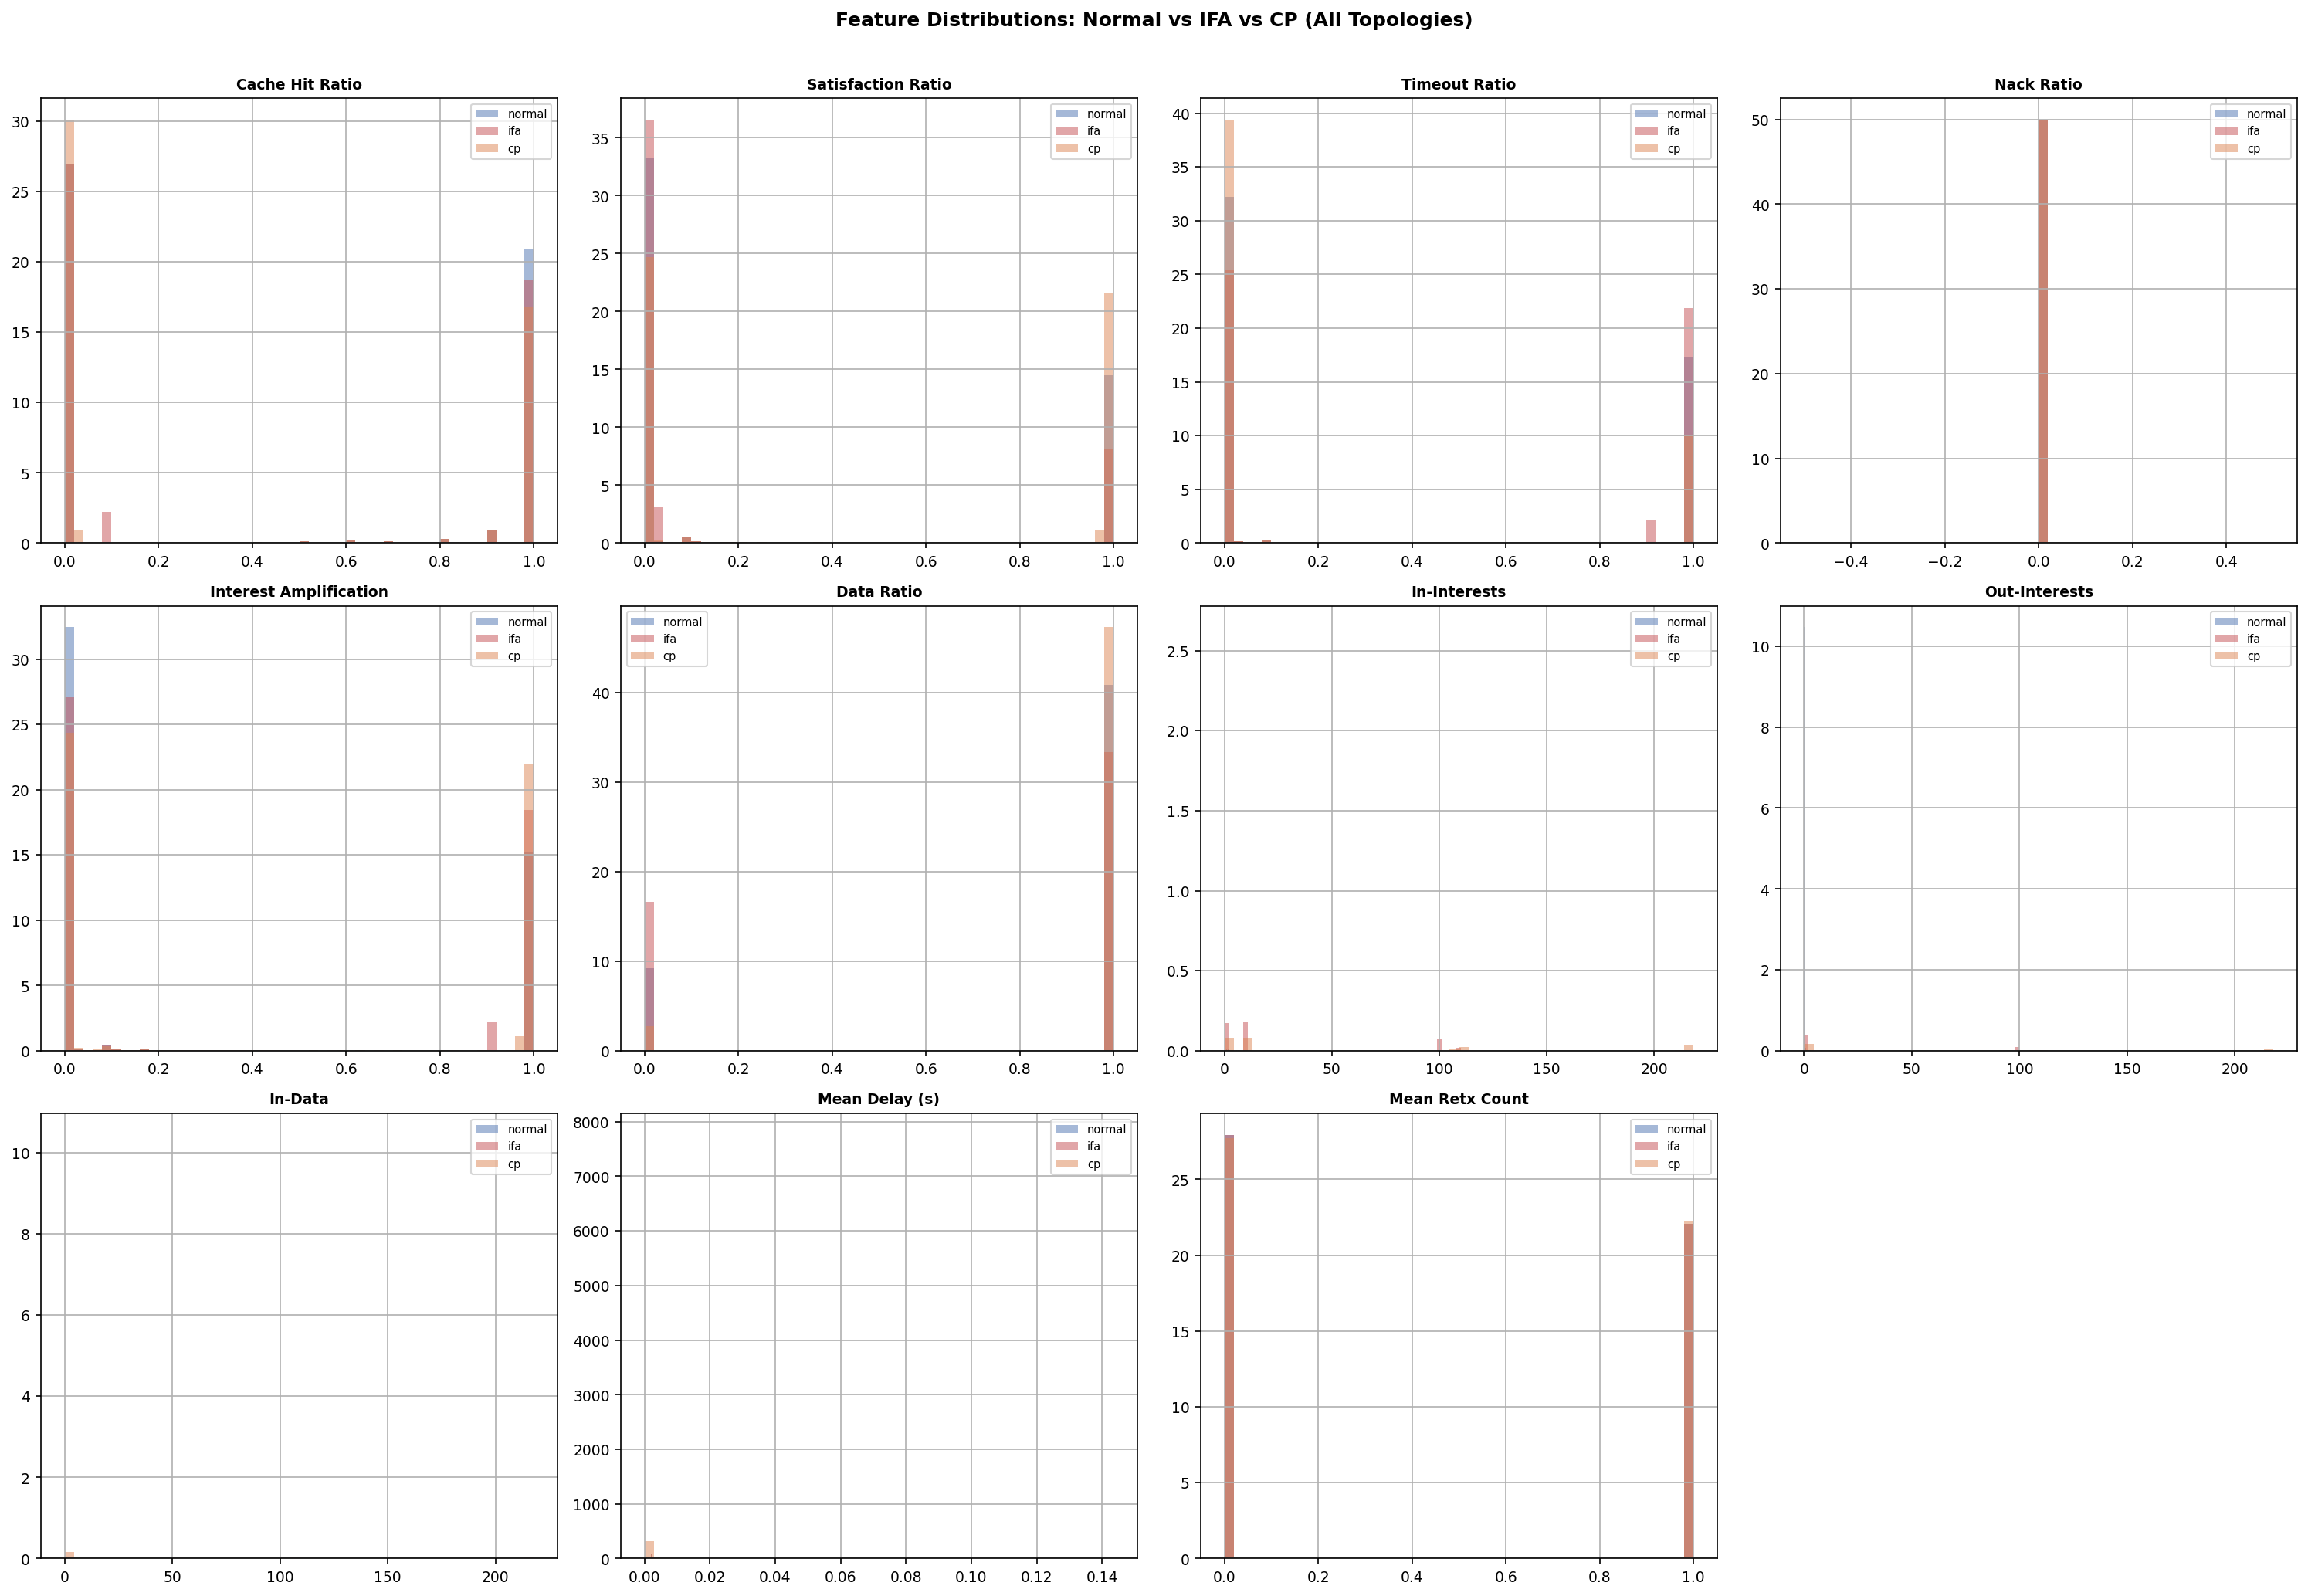

Saved fig_feature_distributions.png


In [4]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    for scenario, color in SCENARIO_COLORS.items():
        vals = full[full["scenario"]==scenario][feat]
        vals.clip(upper=vals.quantile(0.99)).hist(
            bins=50, alpha=0.5, color=color,
            label=scenario, ax=ax, density=True)
    ax.set_title(FEAT_LABELS[feat], fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.set_xlabel("")

# Hide unused subplot
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions: Normal vs IFA vs CP (All Topologies)",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIR / "fig_feature_distributions.png", bbox_inches="tight")
plt.show()
print(f"Saved fig_feature_distributions.png")

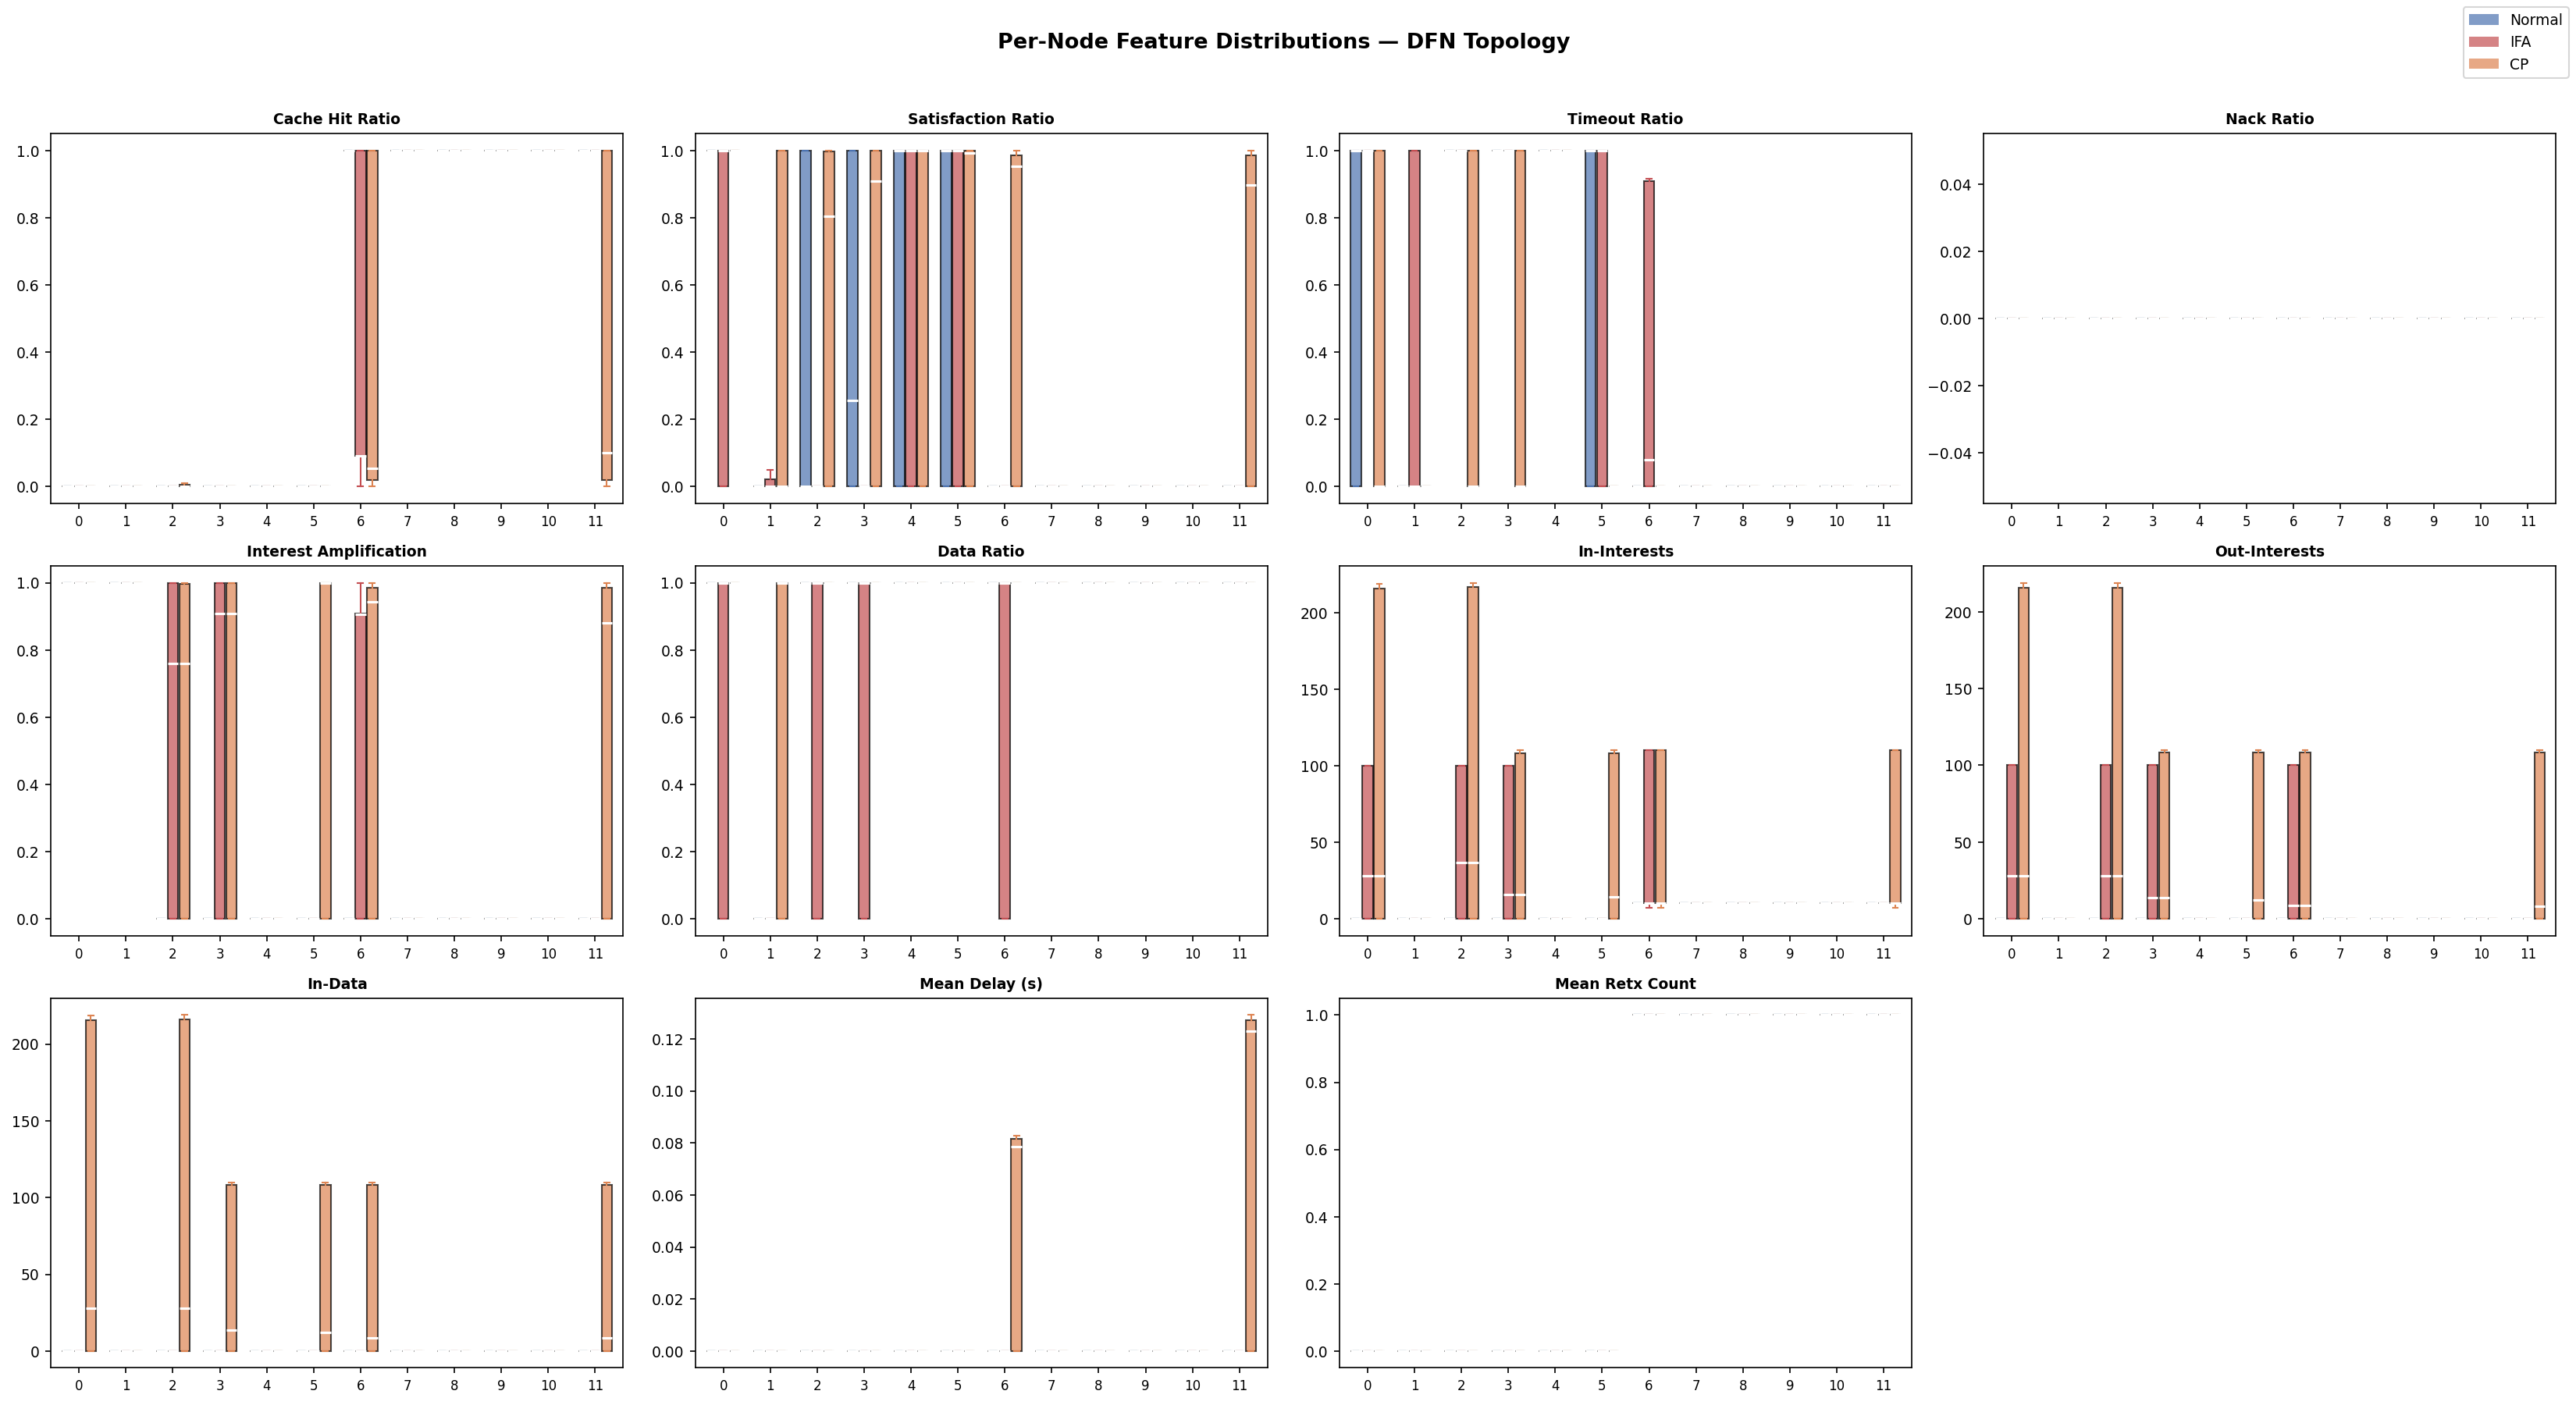

Saved fig_boxplots_dfn.png


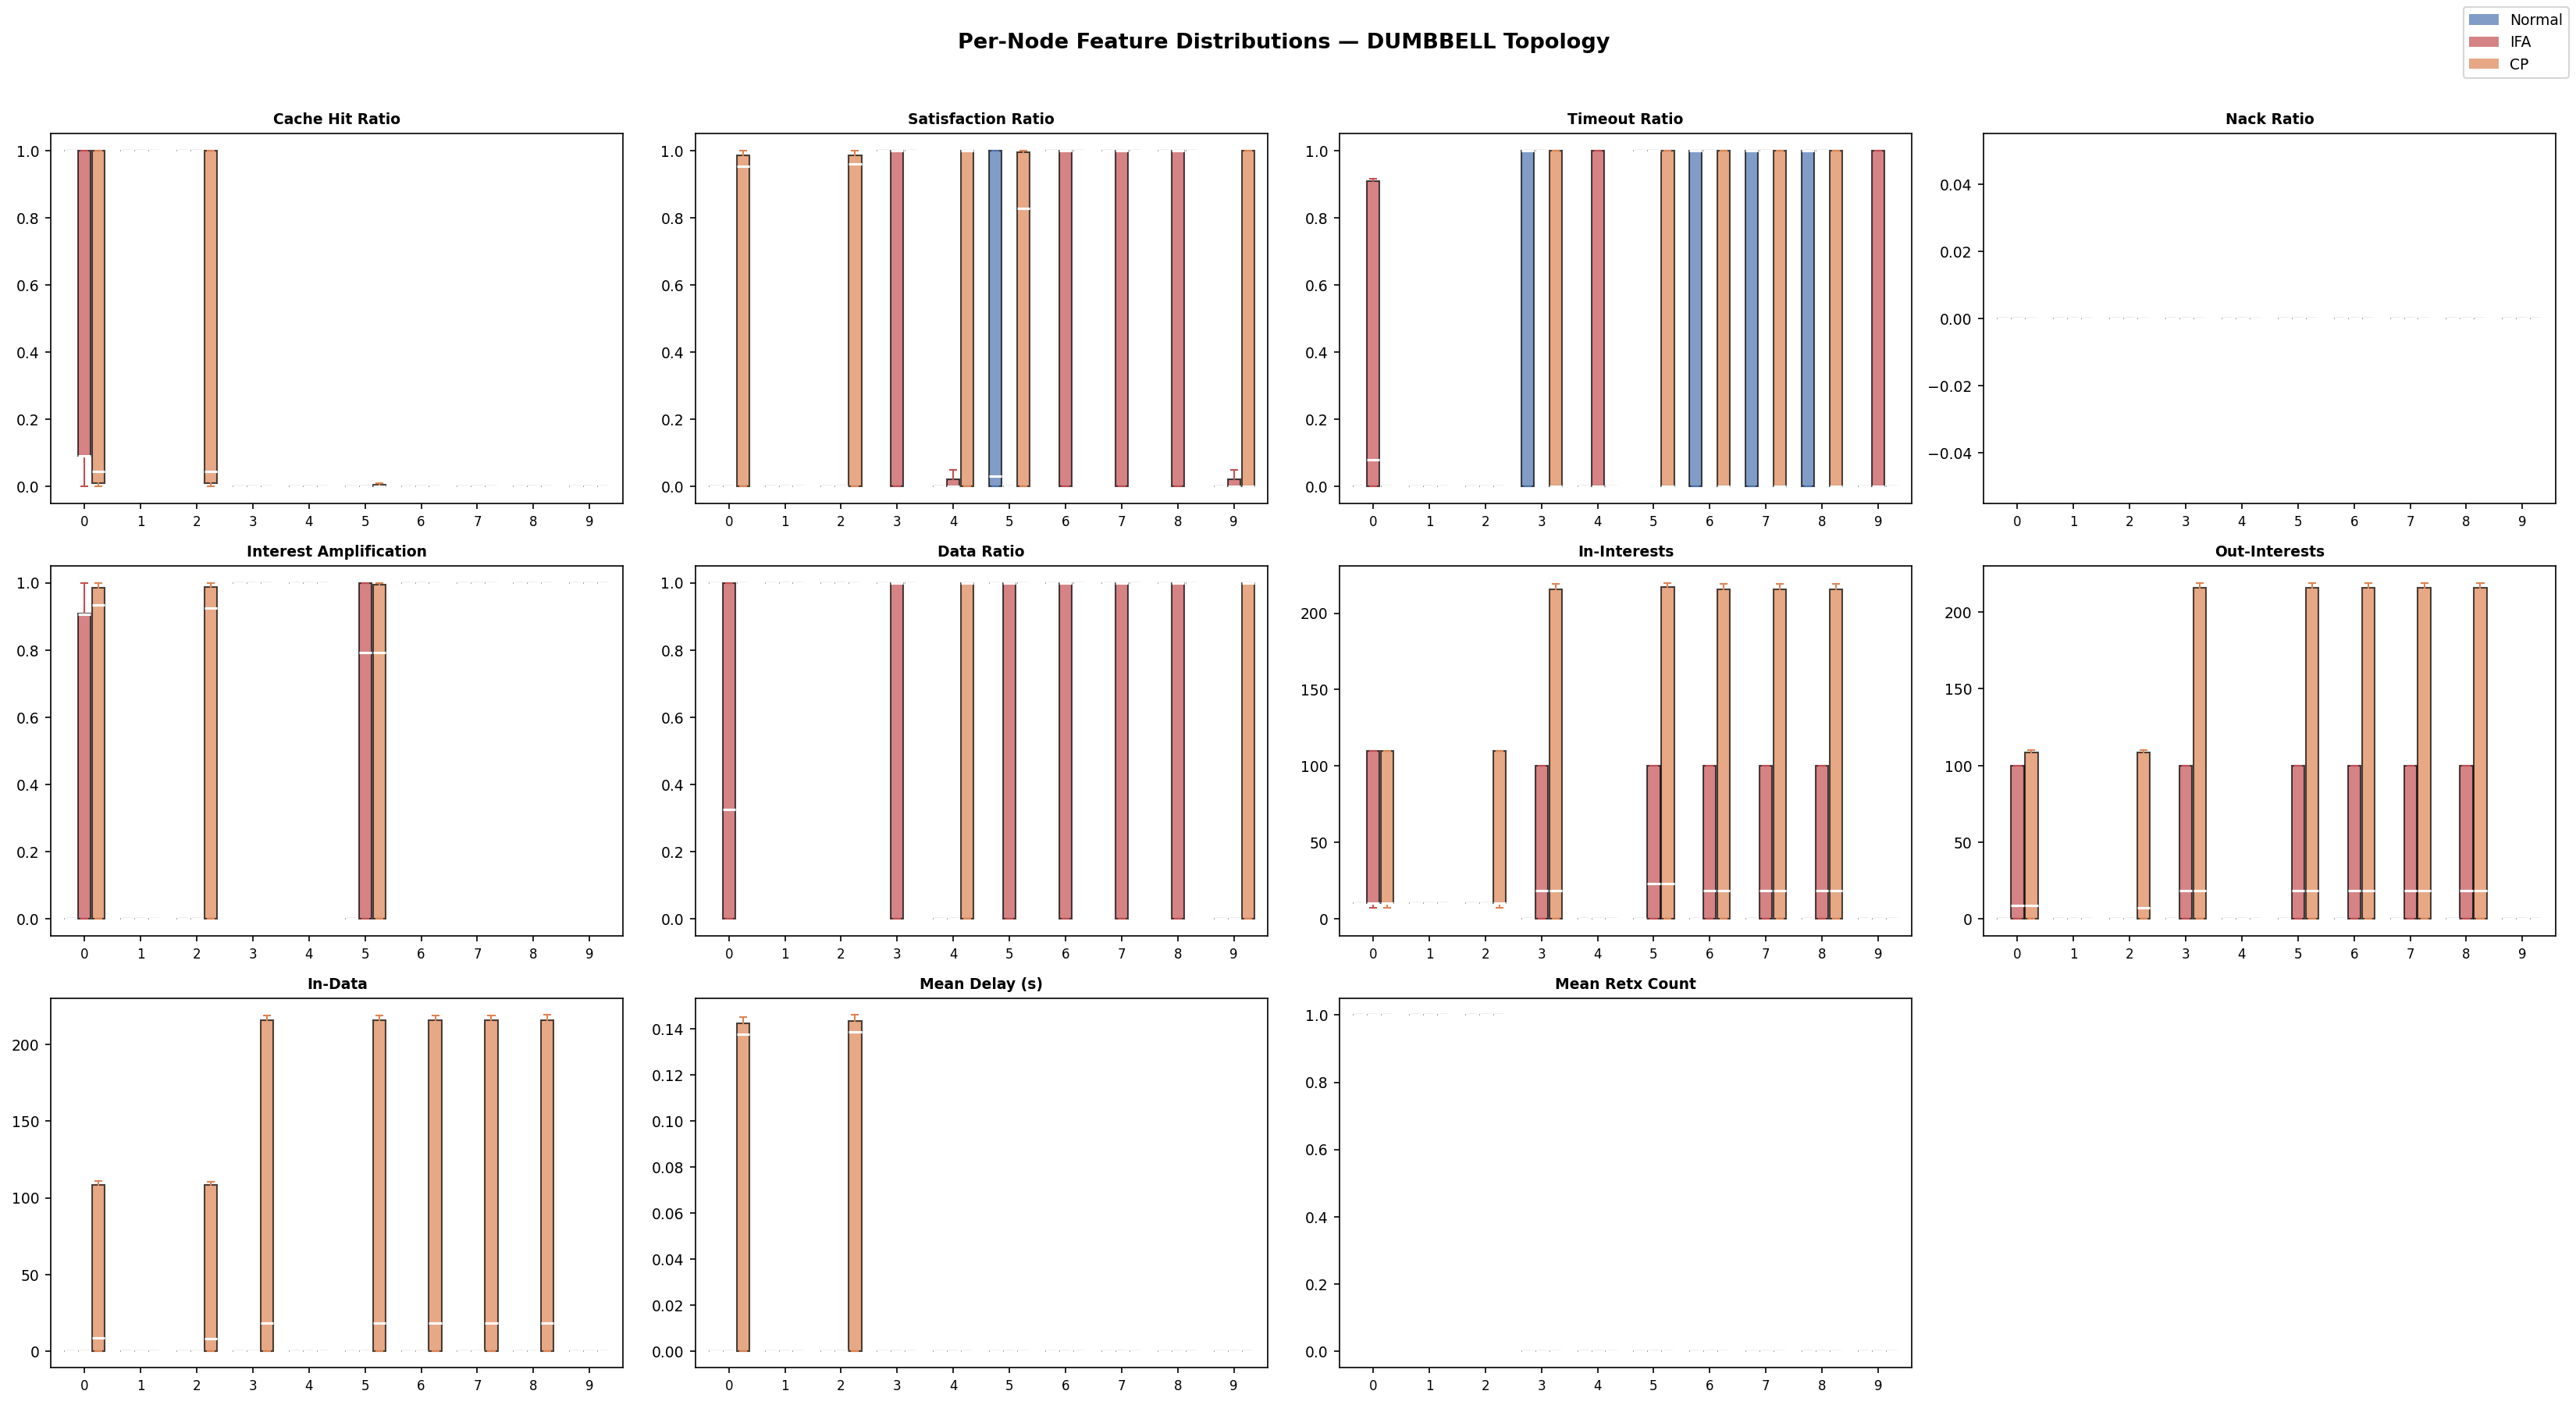

Saved fig_boxplots_dumbbell.png


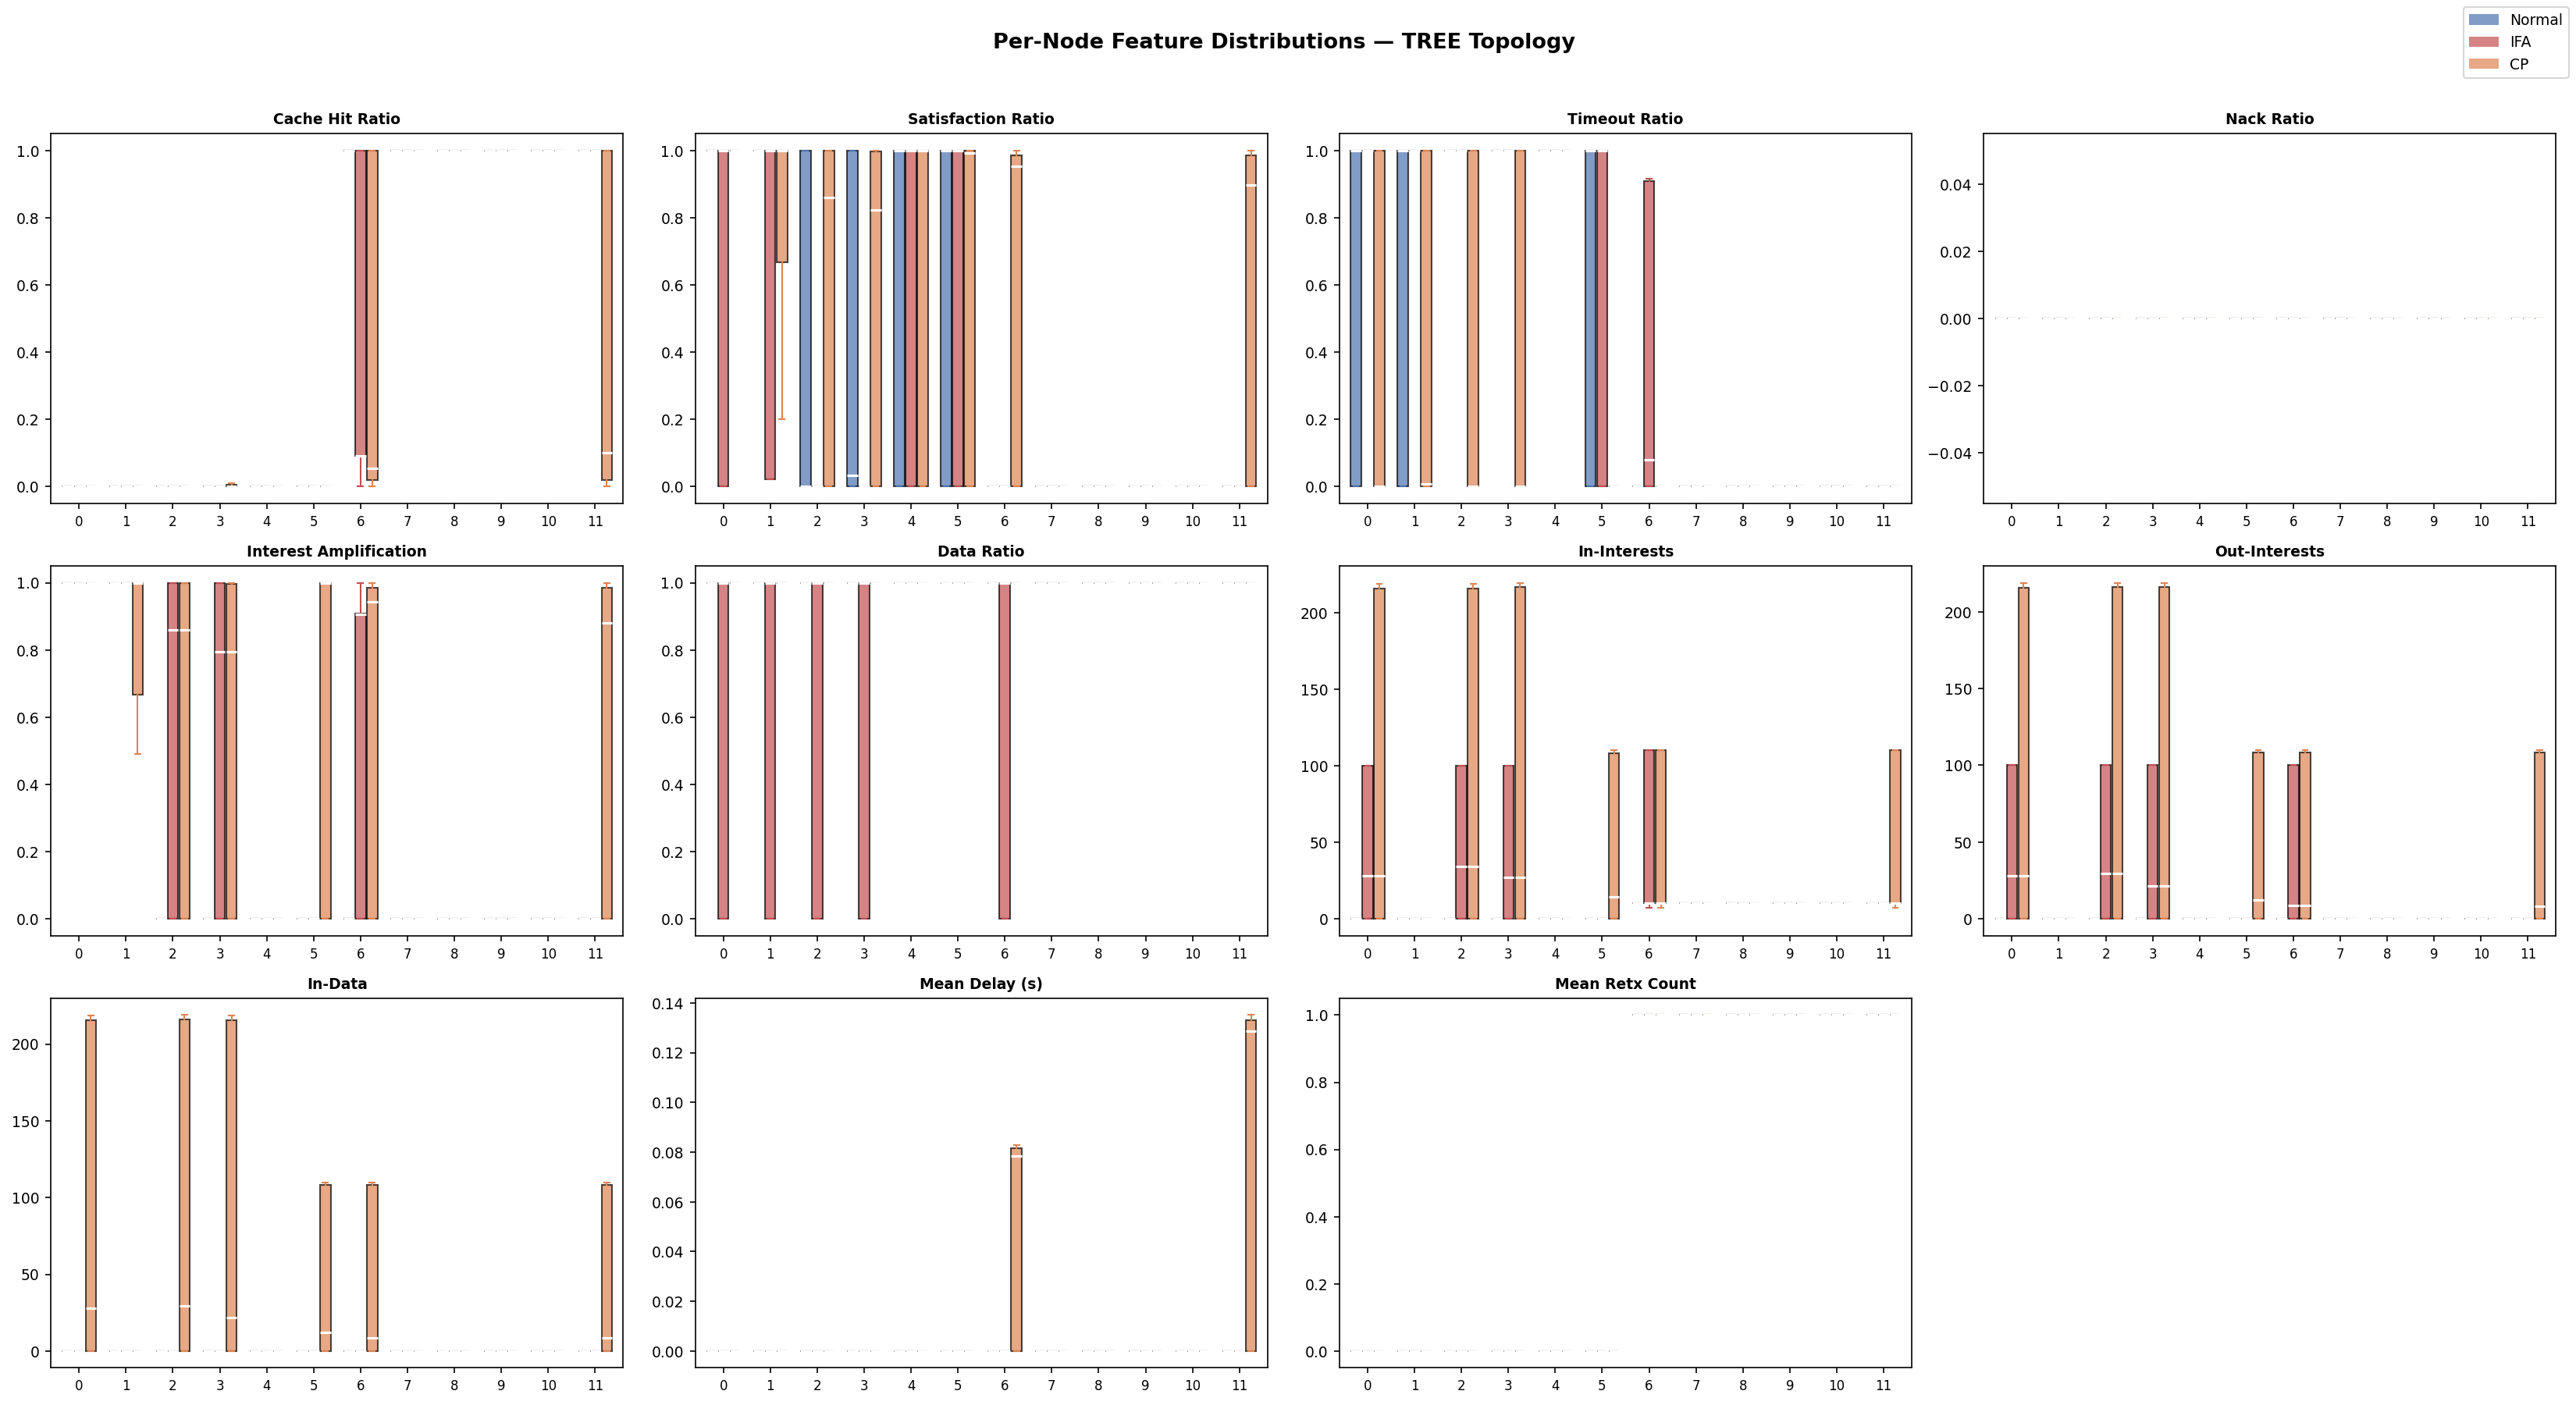

Saved fig_boxplots_tree.png


In [5]:
def plot_pernode_boxplots(topo):
    df_normal = data[topo]["normal"]
    df_ifa    = data[topo]["ifa"]
    df_cp     = data[topo]["cp"]

    nodes  = sorted(full[full["topology"]==topo]["Node"].unique())
    n_feat = len(FEATURES)
    n_cols = 4
    n_rows = int(np.ceil(n_feat / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
    axes = axes.flatten()

    x      = np.arange(len(nodes))
    width  = 0.25

    for fi, feat in enumerate(FEATURES):
        ax = axes[fi]

        norm_data = [df_normal[df_normal["Node"]==n][feat].dropna().values for n in nodes]
        ifa_data  = [df_ifa[df_ifa["Node"]==n][feat].dropna().values for n in nodes]
        cp_data   = [df_cp[df_cp["Node"]==n][feat].dropna().values for n in nodes]

        def bp(data, positions, color):
            return ax.boxplot(data, positions=positions, widths=width*0.9,
                              patch_artist=True, showfliers=False,
                              boxprops=dict(facecolor=color, alpha=0.7),
                              medianprops=dict(color="white", linewidth=1.5),
                              whiskerprops=dict(color=color),
                              capprops=dict(color=color))

        bp(norm_data, x - width, SCENARIO_COLORS["normal"])
        bp(ifa_data,  x,         SCENARIO_COLORS["ifa"])
        bp(cp_data,   x + width, SCENARIO_COLORS["cp"])

        ax.set_xticks(x)
        ax.set_xticklabels(nodes, fontsize=8)
        ax.set_title(FEAT_LABELS[feat], fontsize=9, fontweight="bold")
        ax.set_xlim(-0.6, len(nodes) - 0.4)

    # Hide unused
    for j in range(n_feat, len(axes)):
        axes[j].set_visible(False)

    legend_patches = [
        Patch(facecolor=SCENARIO_COLORS["normal"], alpha=0.7, label="Normal"),
        Patch(facecolor=SCENARIO_COLORS["ifa"],    alpha=0.7, label="IFA"),
        Patch(facecolor=SCENARIO_COLORS["cp"],     alpha=0.7, label="CP"),
    ]
    fig.legend(handles=legend_patches, loc="upper right", fontsize=9)
    fig.suptitle(f"Per-Node Feature Distributions — {topo.upper()} Topology",
                 fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fname = FIG_DIR / f"fig_boxplots_{topo}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    plot_pernode_boxplots(topo)

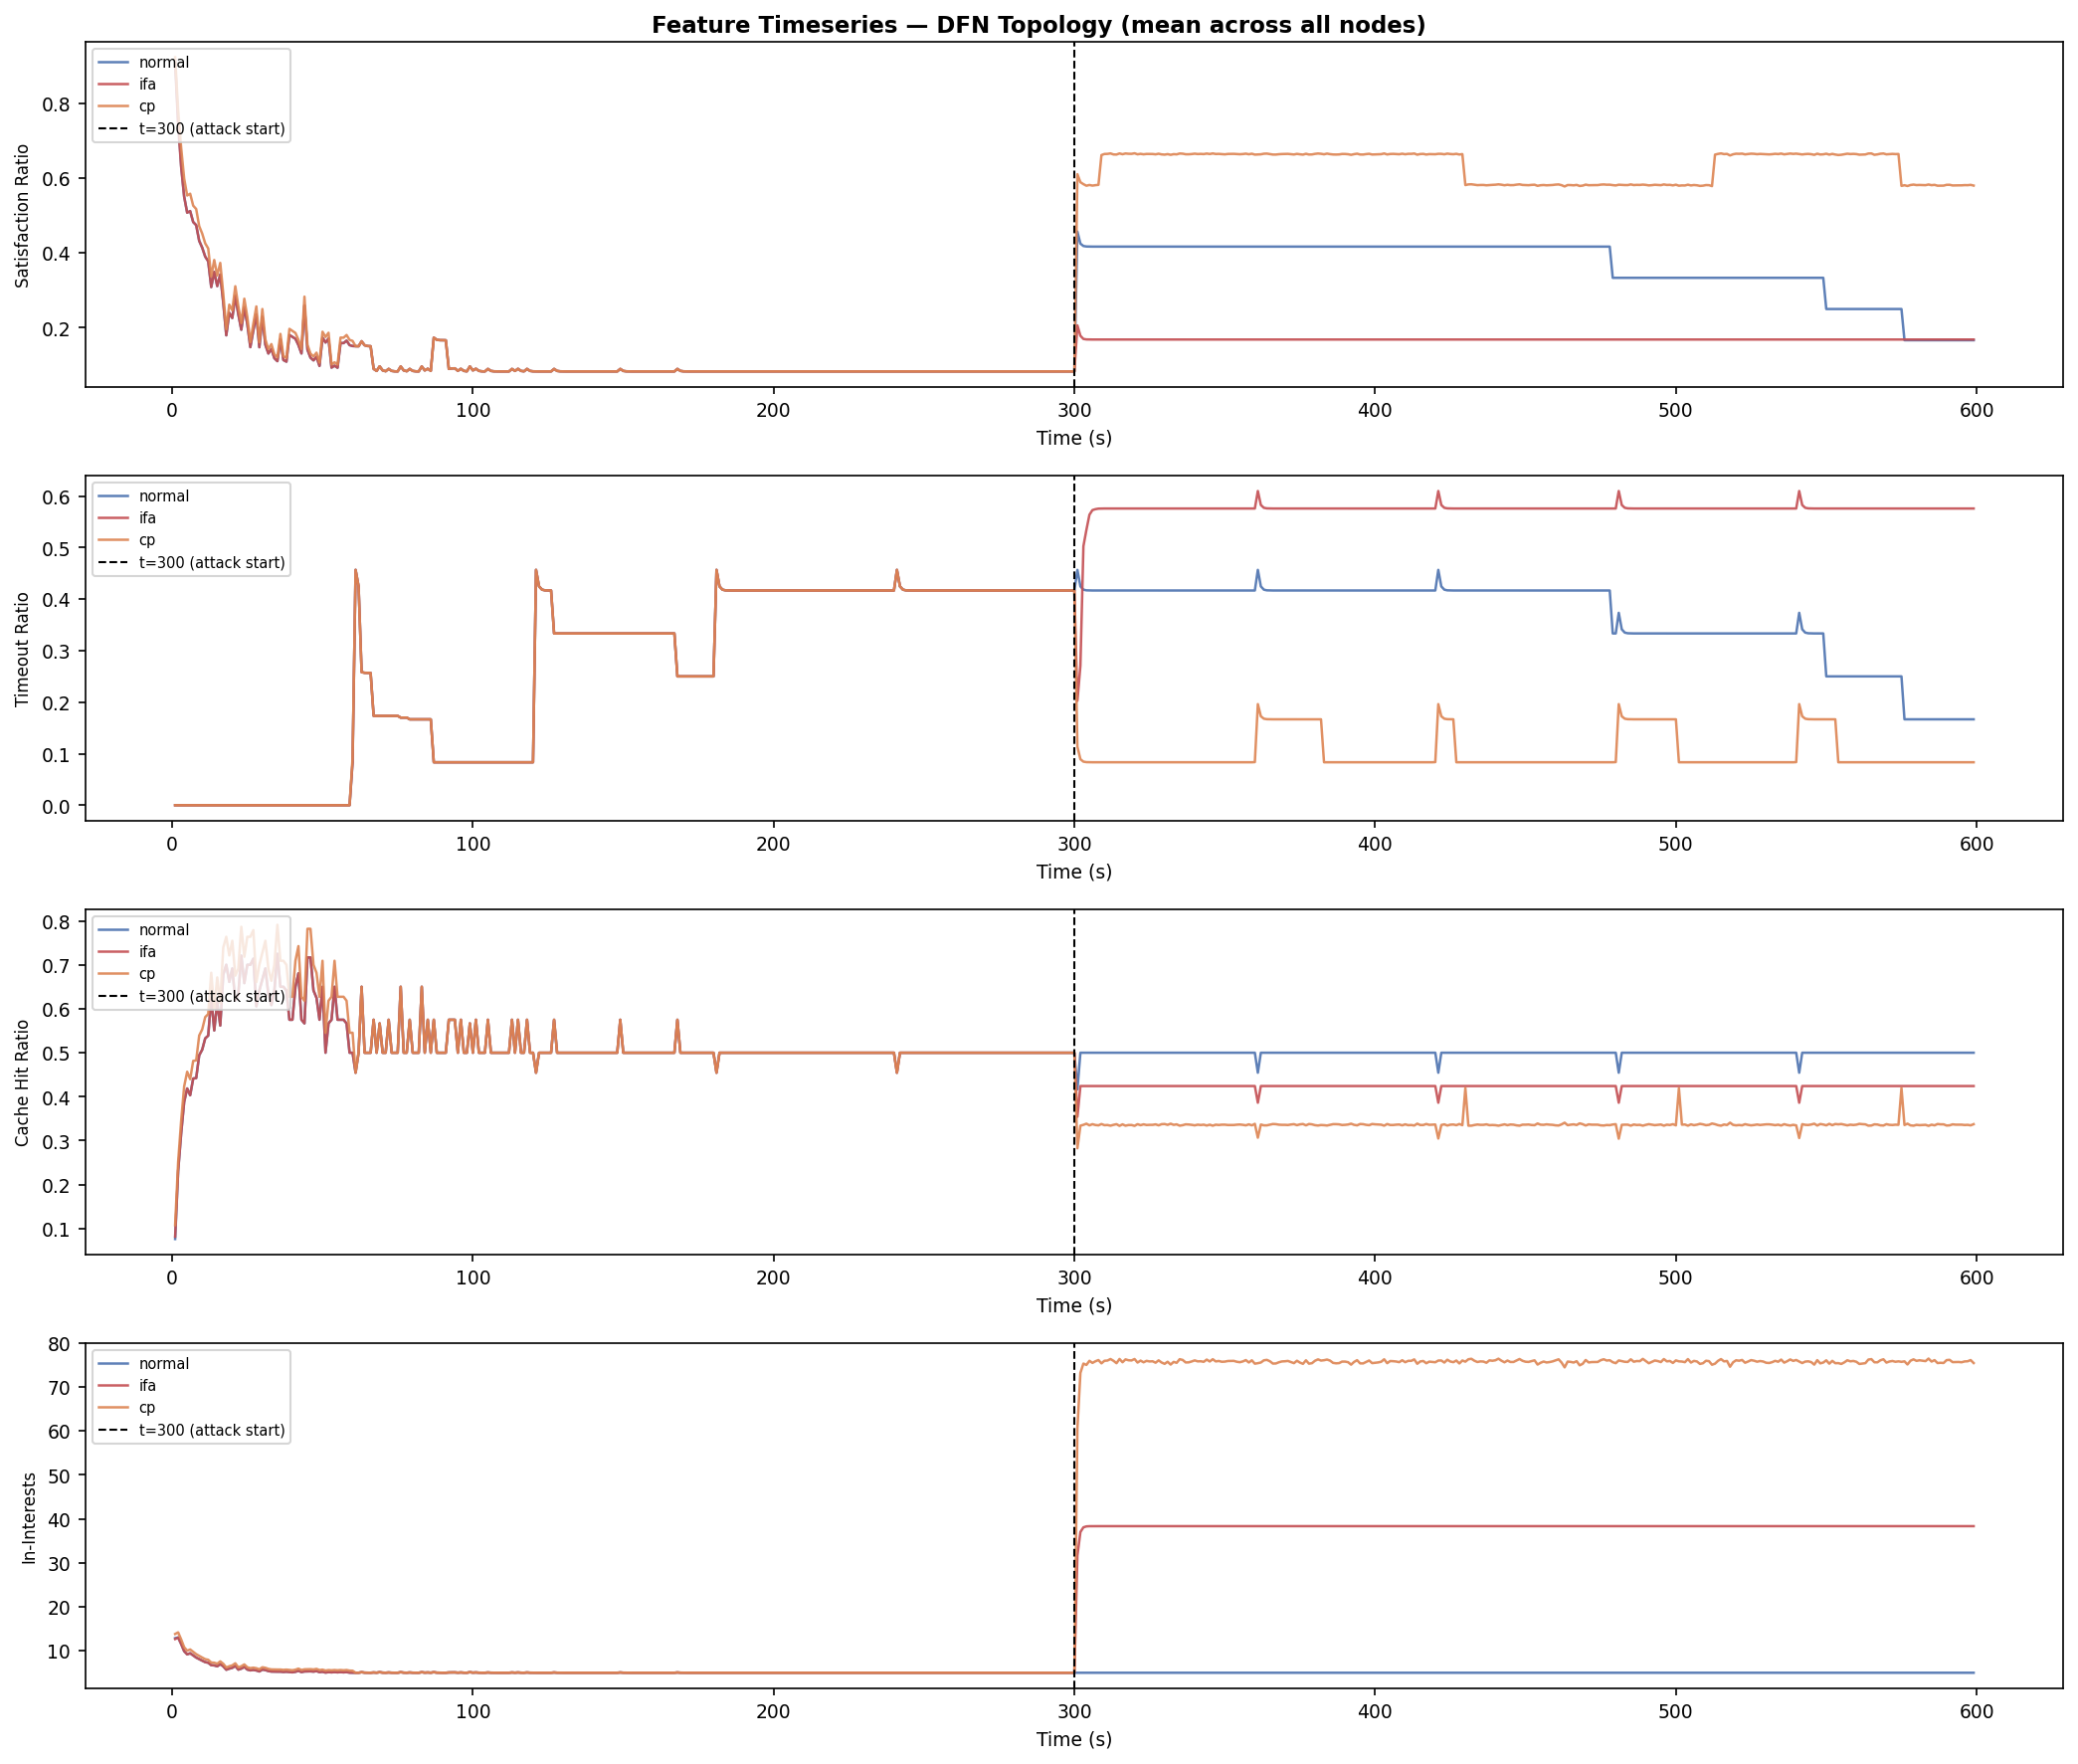

Saved fig_timeseries_dfn.png


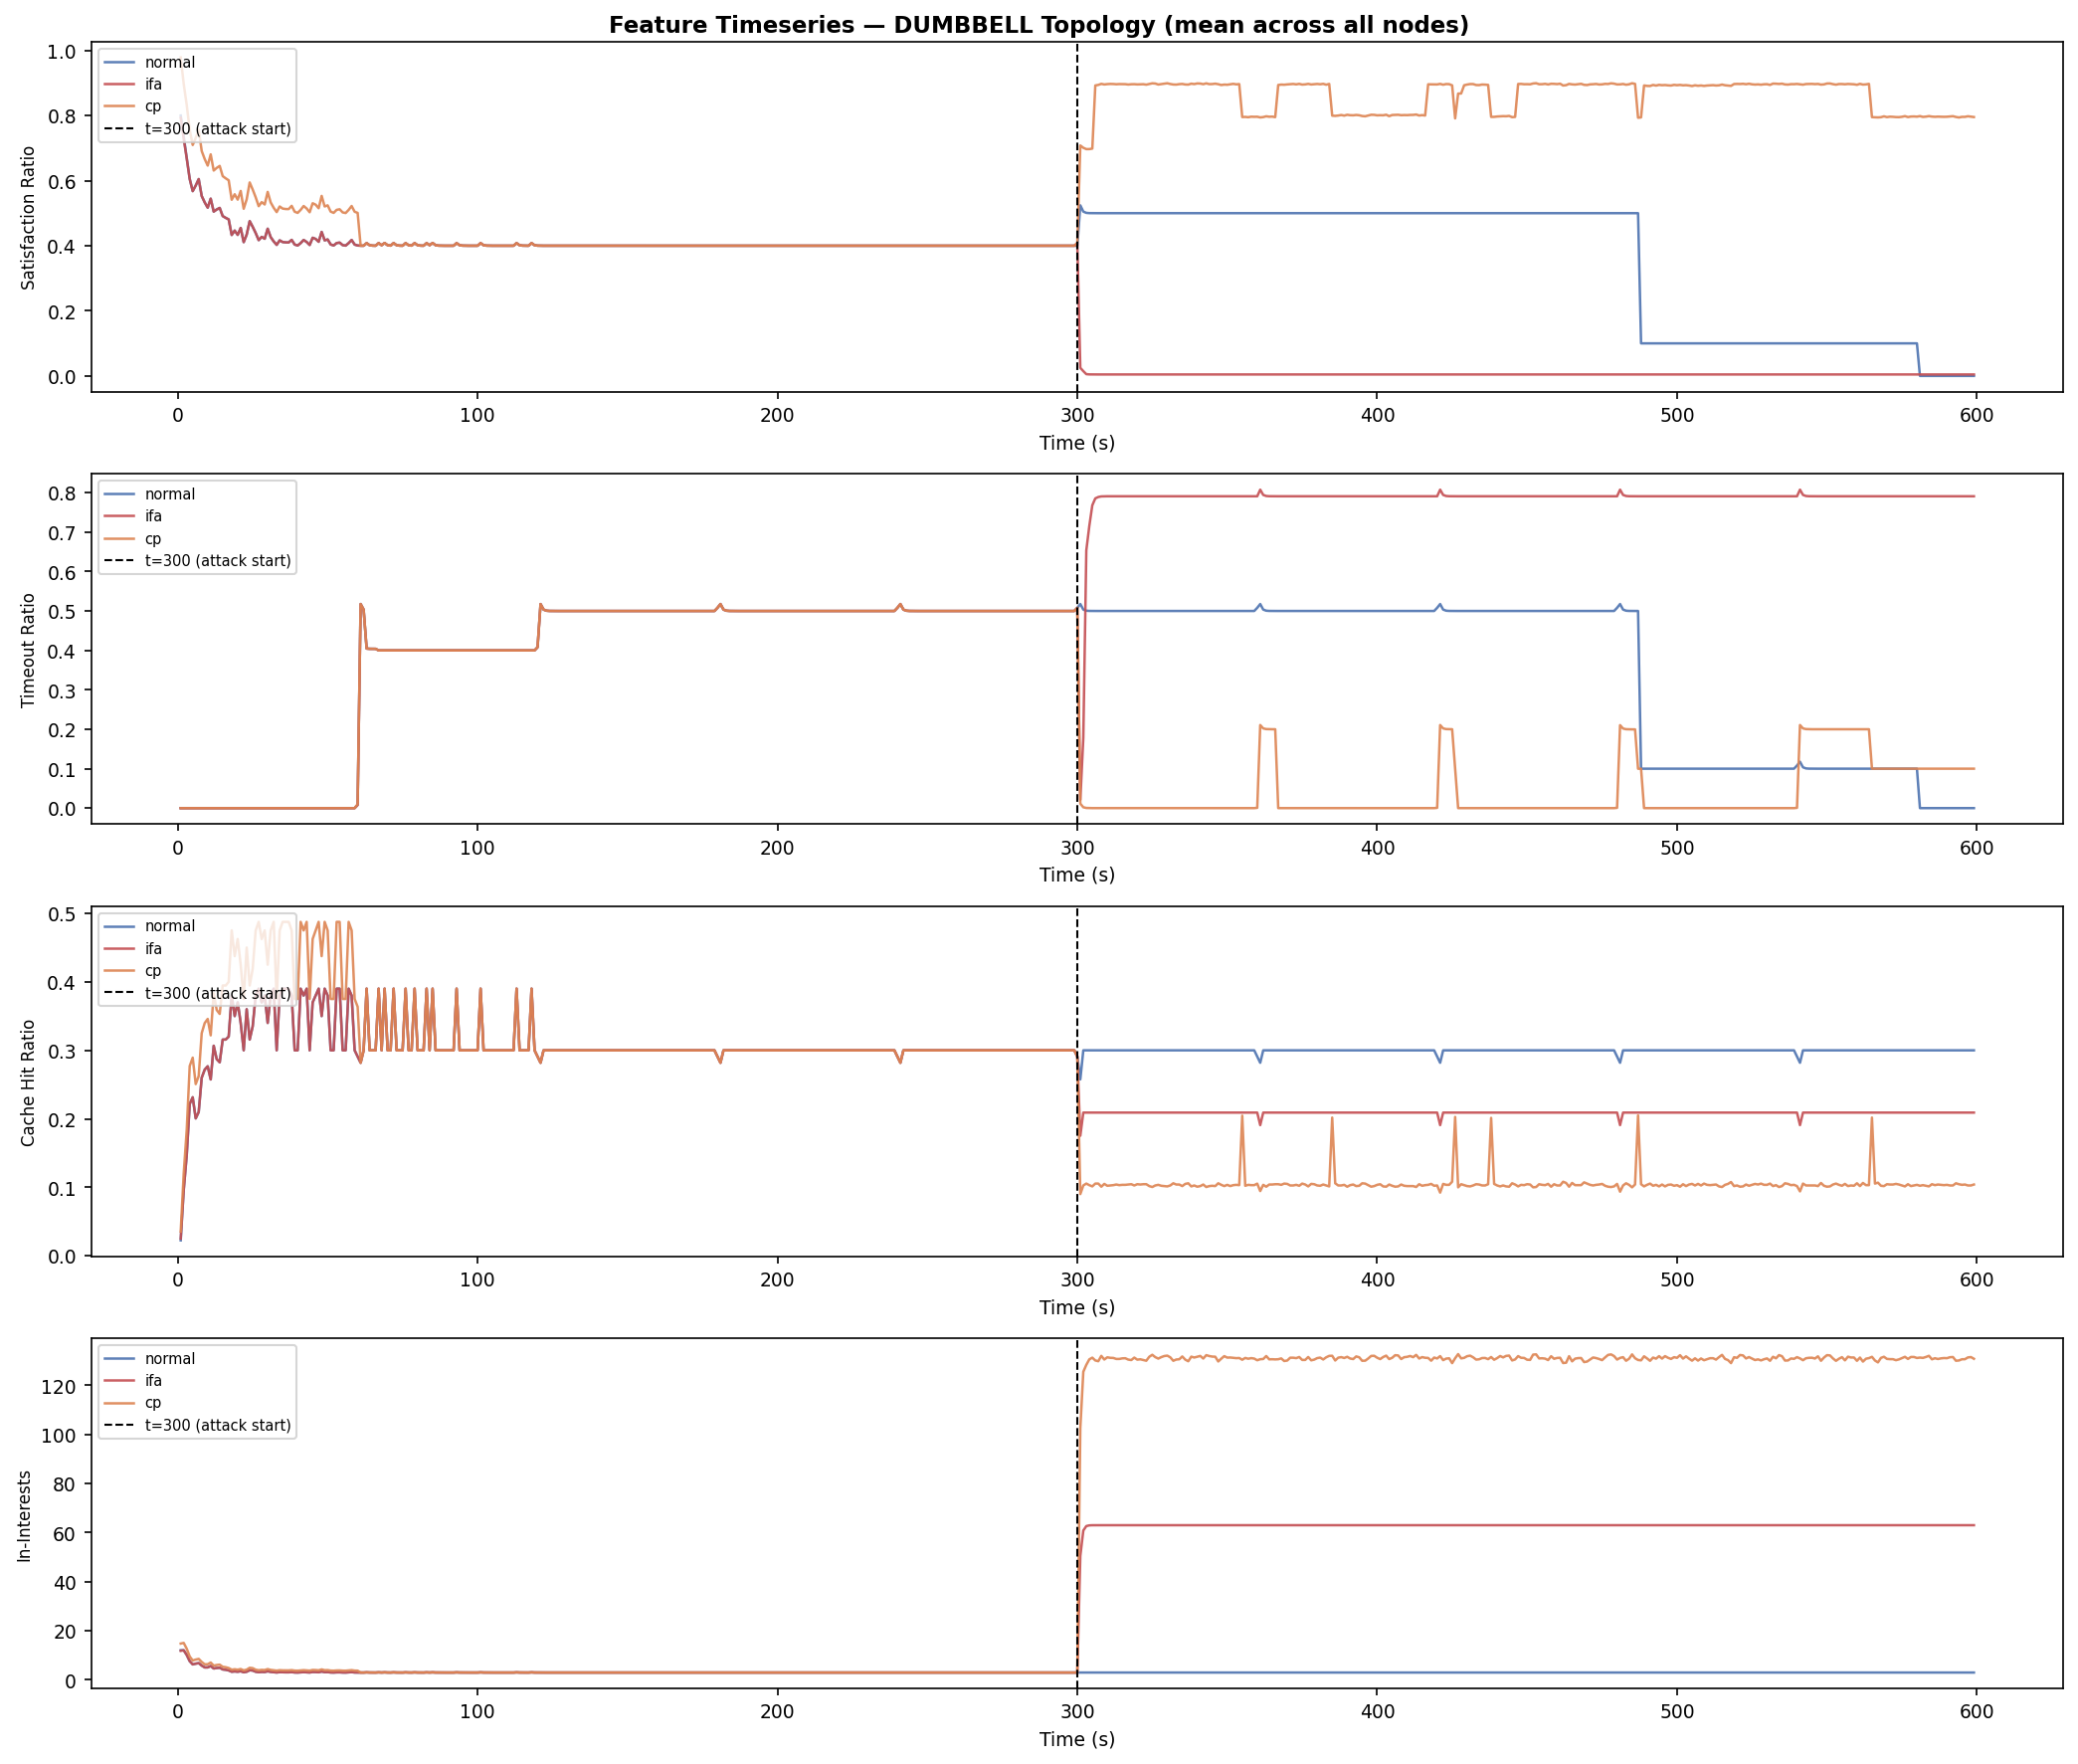

Saved fig_timeseries_dumbbell.png


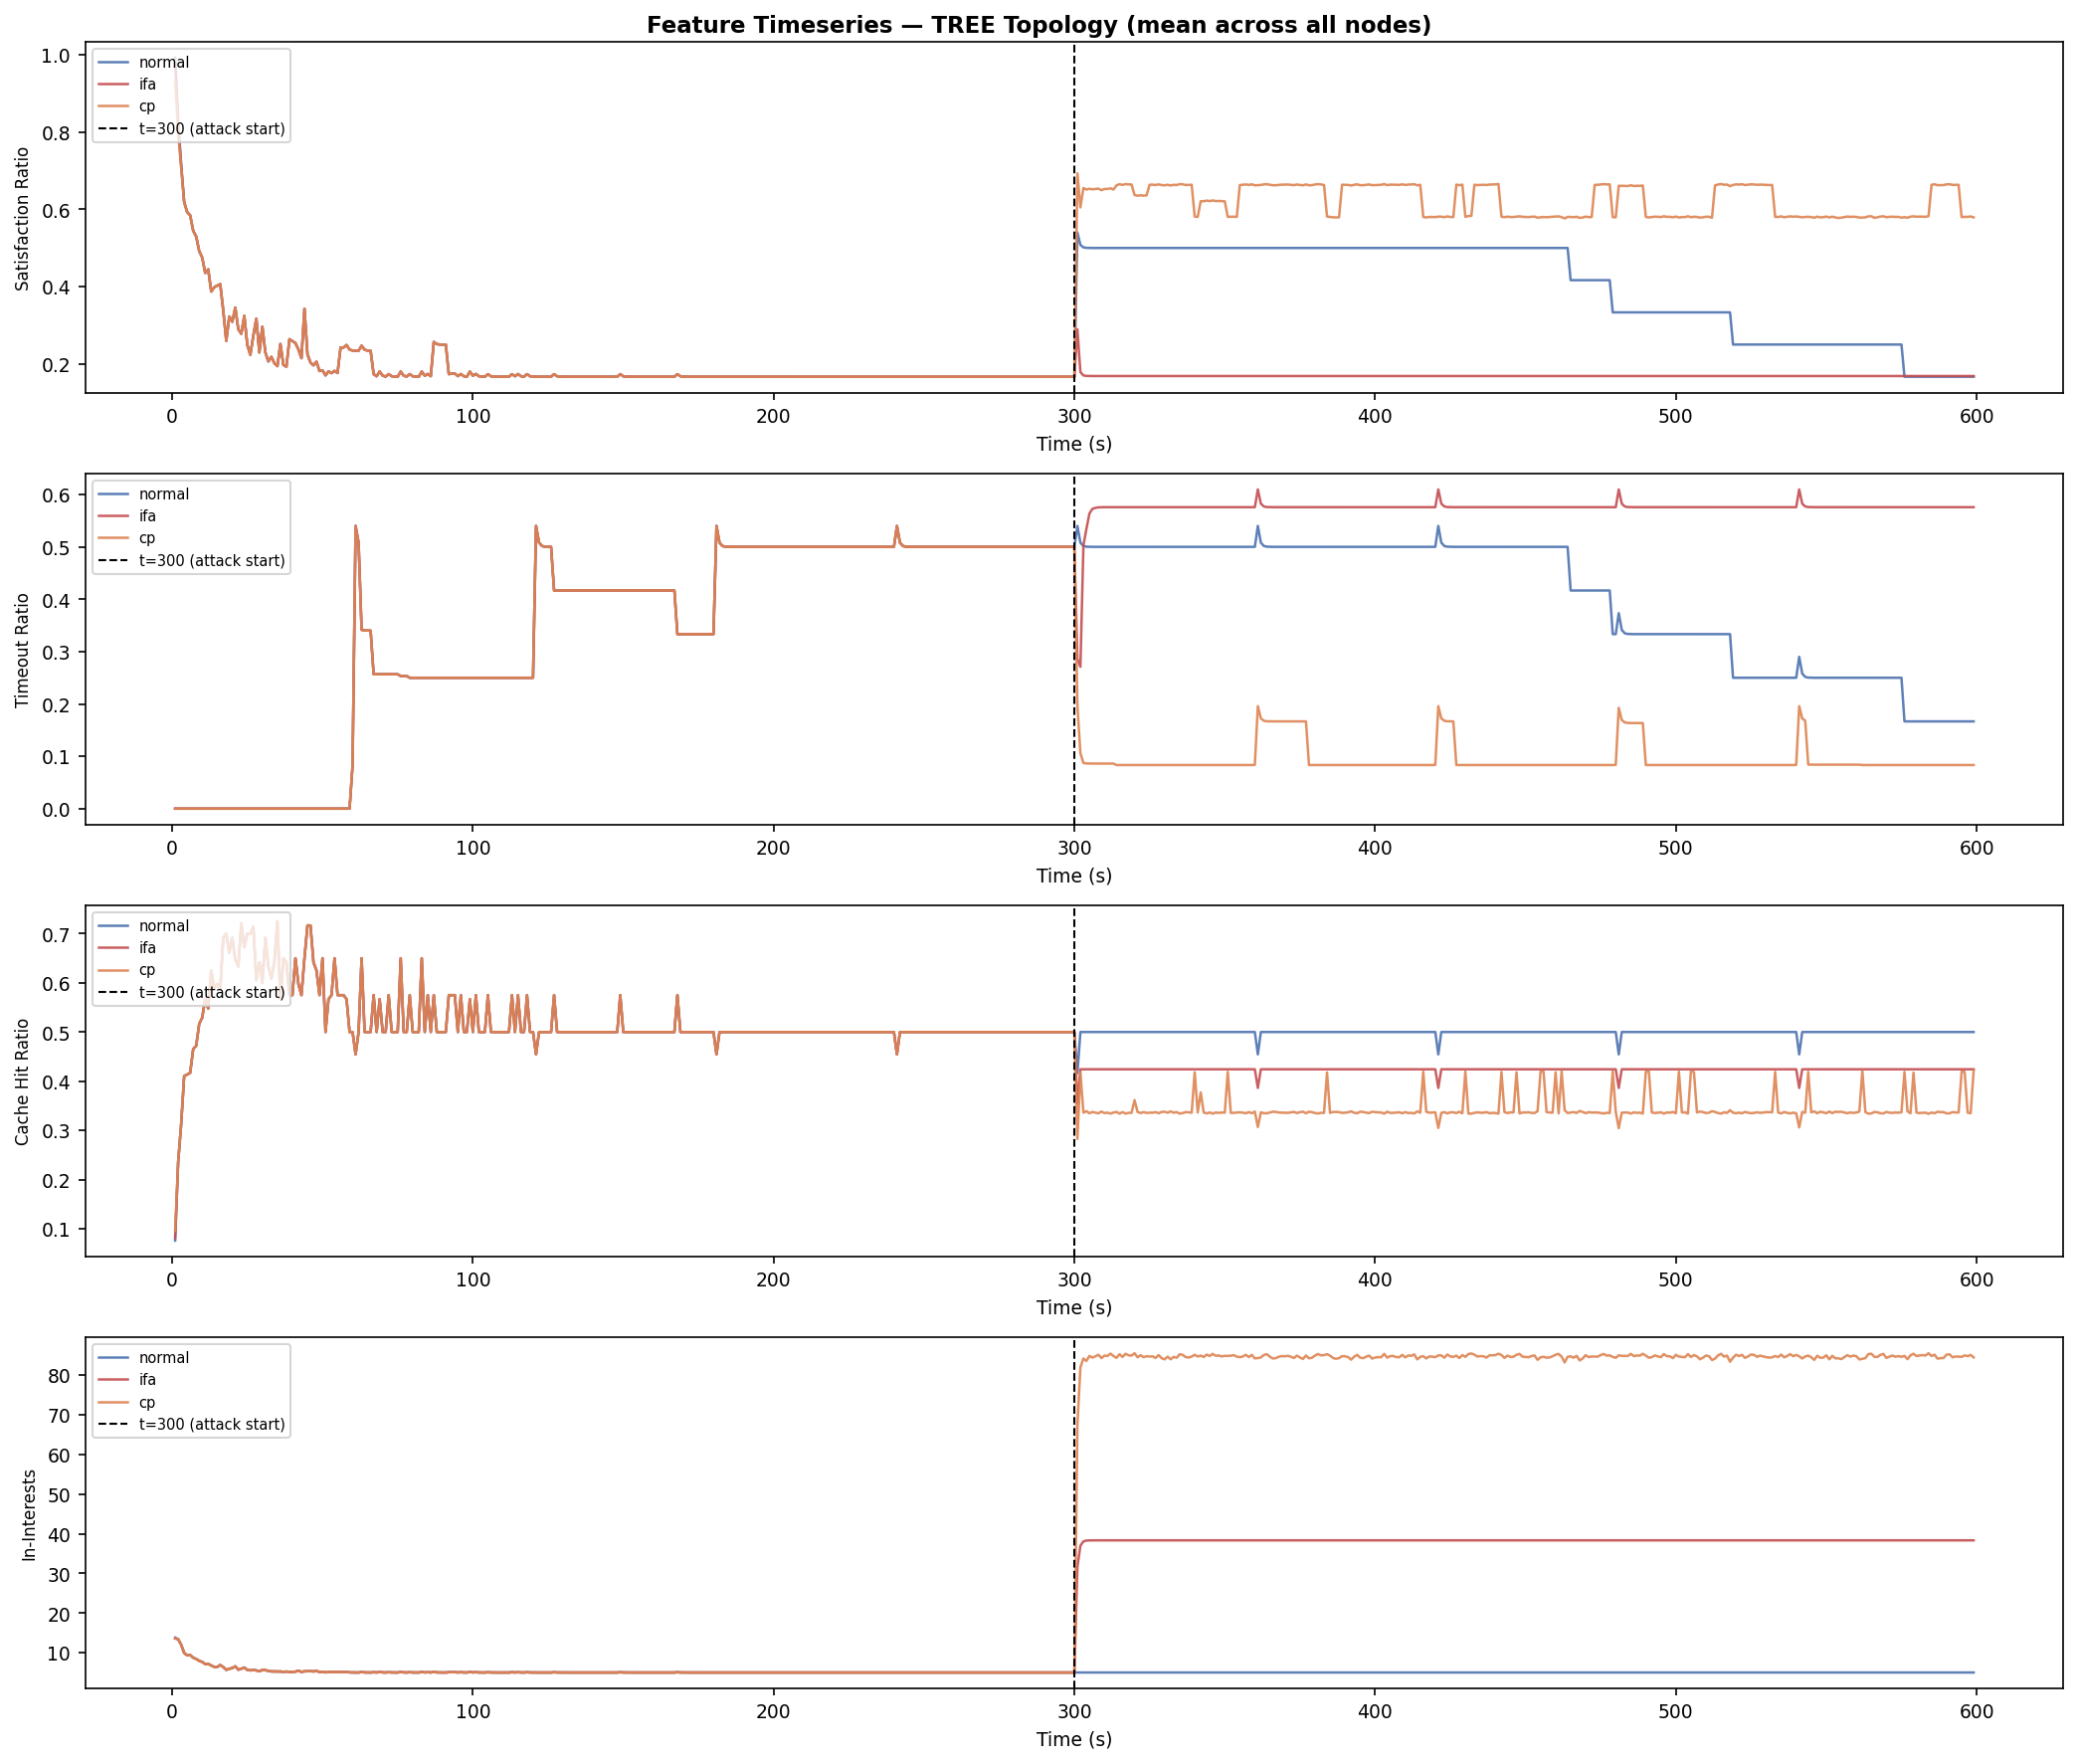

Saved fig_timeseries_tree.png


In [6]:
KEY_FEATURES = [
    "satisfaction_ratio", "timeout_ratio",
    "cache_hit_ratio", "InInterests"
]

def plot_timeseries(topo):
    fig, axes = plt.subplots(len(KEY_FEATURES), 1, figsize=(14, 3 * len(KEY_FEATURES)))

    for i, feat in enumerate(KEY_FEATURES):
        ax = axes[i]
        for scenario, color in SCENARIO_COLORS.items():
            grp = data[topo][scenario]
            ts  = grp.groupby("Time")[feat].mean()
            ax.plot(ts.index, ts.values, color=color,
                    label=scenario, linewidth=1.2, alpha=0.9)
        ax.axvline(300, color="black", linestyle="--",
                   linewidth=1.0, label="t=300 (attack start)")
        ax.set_ylabel(FEAT_LABELS[feat], fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.set_xlabel("Time (s)")

    fig.suptitle(f"Feature Timeseries — {topo.upper()} Topology (mean across all nodes)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    fname = FIG_DIR / f"fig_timeseries_{topo}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    plot_timeseries(topo)

In [7]:
ks_rows = []
for topo in TOPOLOGIES:
    nodes = sorted(full[full["topology"]==topo]["Node"].unique())
    for node in nodes:
        for attack in ["ifa", "cp"]:
            norm_df = data[topo]["normal"]
            atk_df  = data[topo][attack]
            for feat in FEATURES:
                norm_vals = norm_df[norm_df["Node"]==node][feat].dropna().values
                atk_vals  = atk_df[atk_df["Node"]==node][feat].dropna().values
                if len(norm_vals) < 2 or len(atk_vals) < 2:
                    ks_stat, p_val = np.nan, np.nan
                else:
                    ks_stat, p_val = ks_2samp(norm_vals, atk_vals)
                ks_rows.append({
                    "topology": topo, "node": node,
                    "attack": attack, "feature": feat,
                    "ks_stat": ks_stat, "p_value": p_val,
                    "role": full[(full["topology"]==topo) &
                                 (full["Node"]==node)]["role"].iloc[0]
                })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(PROCESSED_DIR / "ks_results.csv", index=False)
print("Saved ks_results.csv")
print("\nTop 15 KS results (IFA, all topologies):")
print(df_ks[df_ks["attack"]=="ifa"]
      .sort_values("ks_stat", ascending=False)
      .head(15)[["topology","node","role","feature","ks_stat"]].to_string(index=False))

Saved ks_results.csv

Top 15 KS results (IFA, all topologies):
topology  node     role         feature  ks_stat
dumbbell     5   router     InInterests 0.499165
    tree     2   router     InInterests 0.499165
dumbbell     7   router     InInterests 0.499165
    tree     0   router    OutInterests 0.499165
     dfn     3   router     InInterests 0.499165
     dfn     3   router    OutInterests 0.499165
dumbbell     6   router    OutInterests 0.499165
dumbbell     6   router     InInterests 0.499165
dumbbell     5   router    OutInterests 0.499165
     dfn     6 consumer cache_hit_ratio 0.499165
     dfn     6 consumer    interest_amp 0.499165
     dfn     6 consumer     InInterests 0.499165
     dfn     6 consumer    OutInterests 0.499165
    tree     2   router    OutInterests 0.499165
     dfn     2   router     InInterests 0.499165


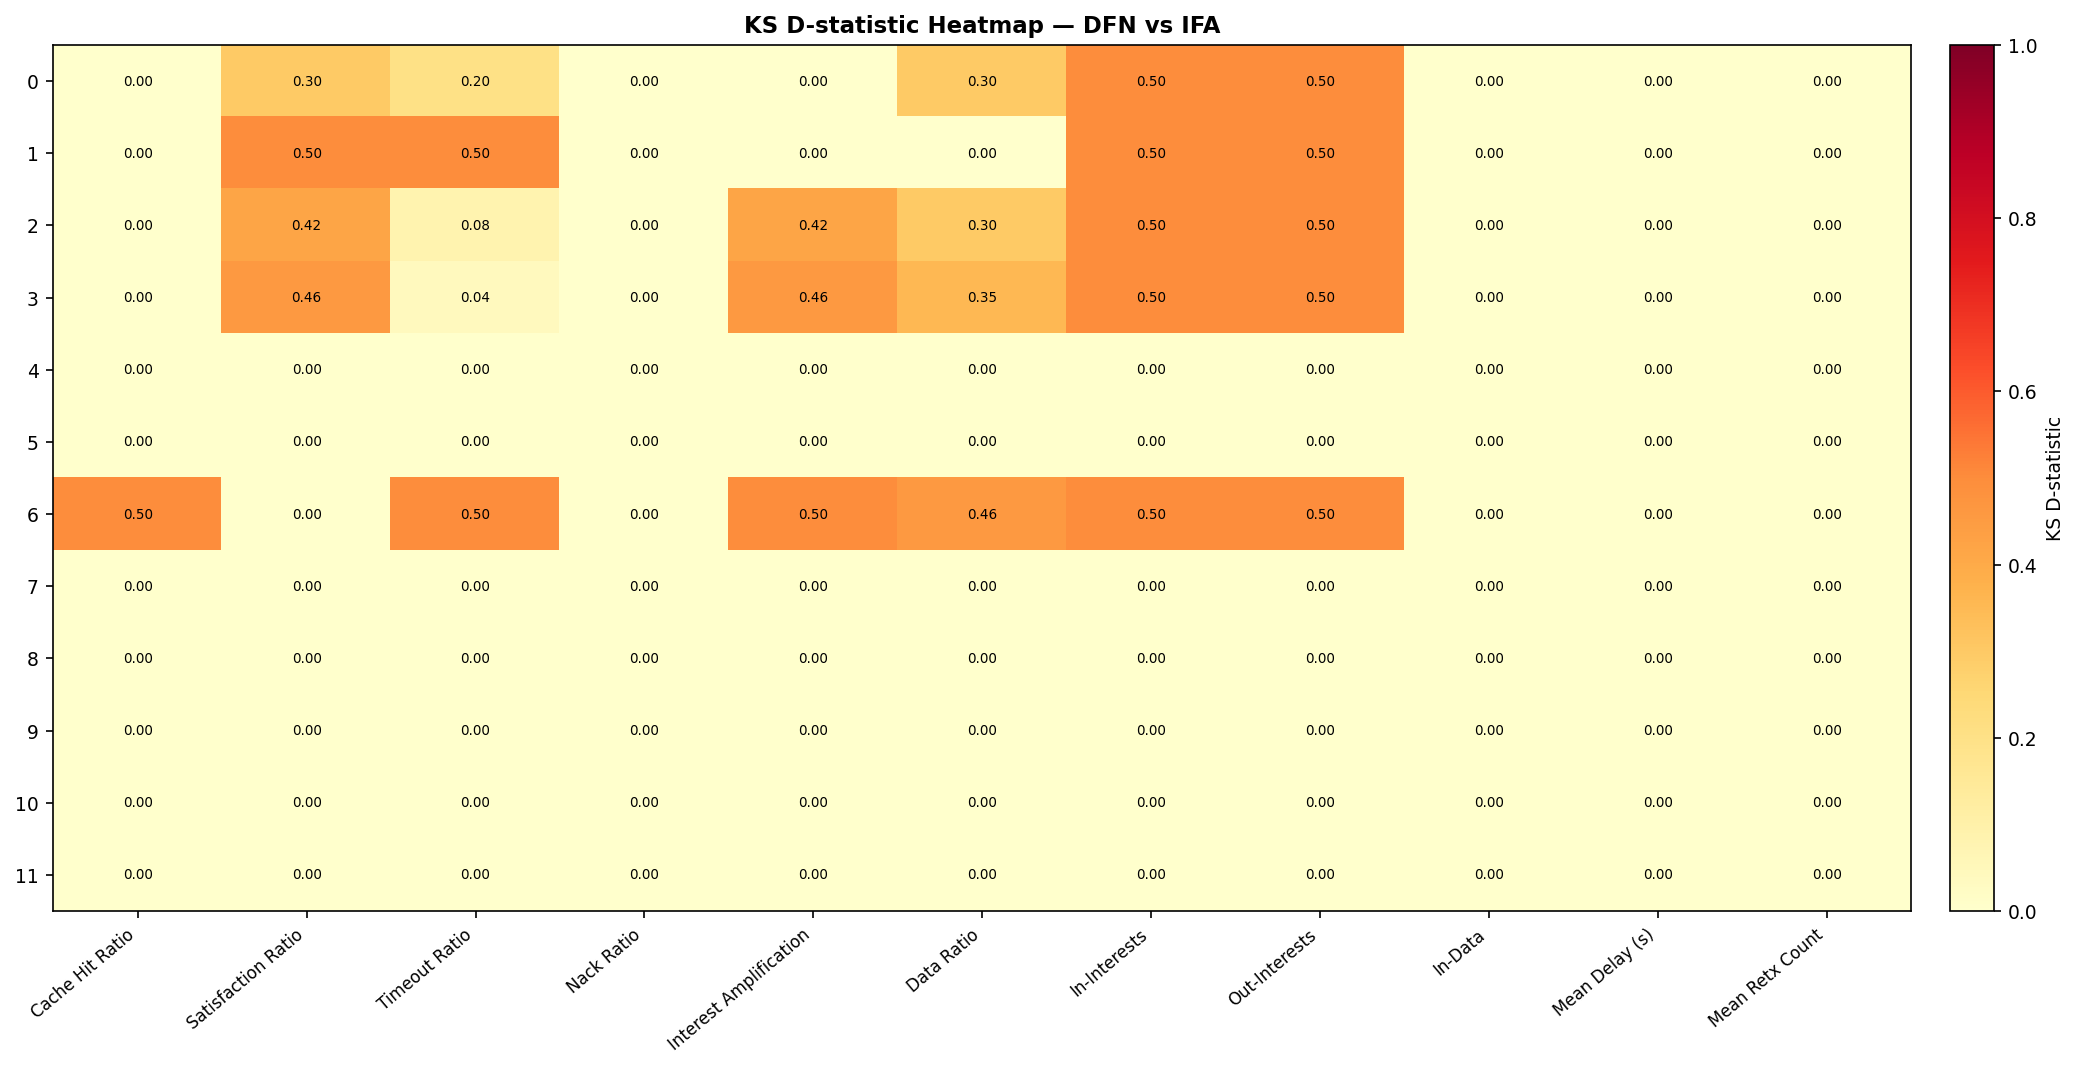

Saved fig_ks_heatmap_dfn_ifa.png


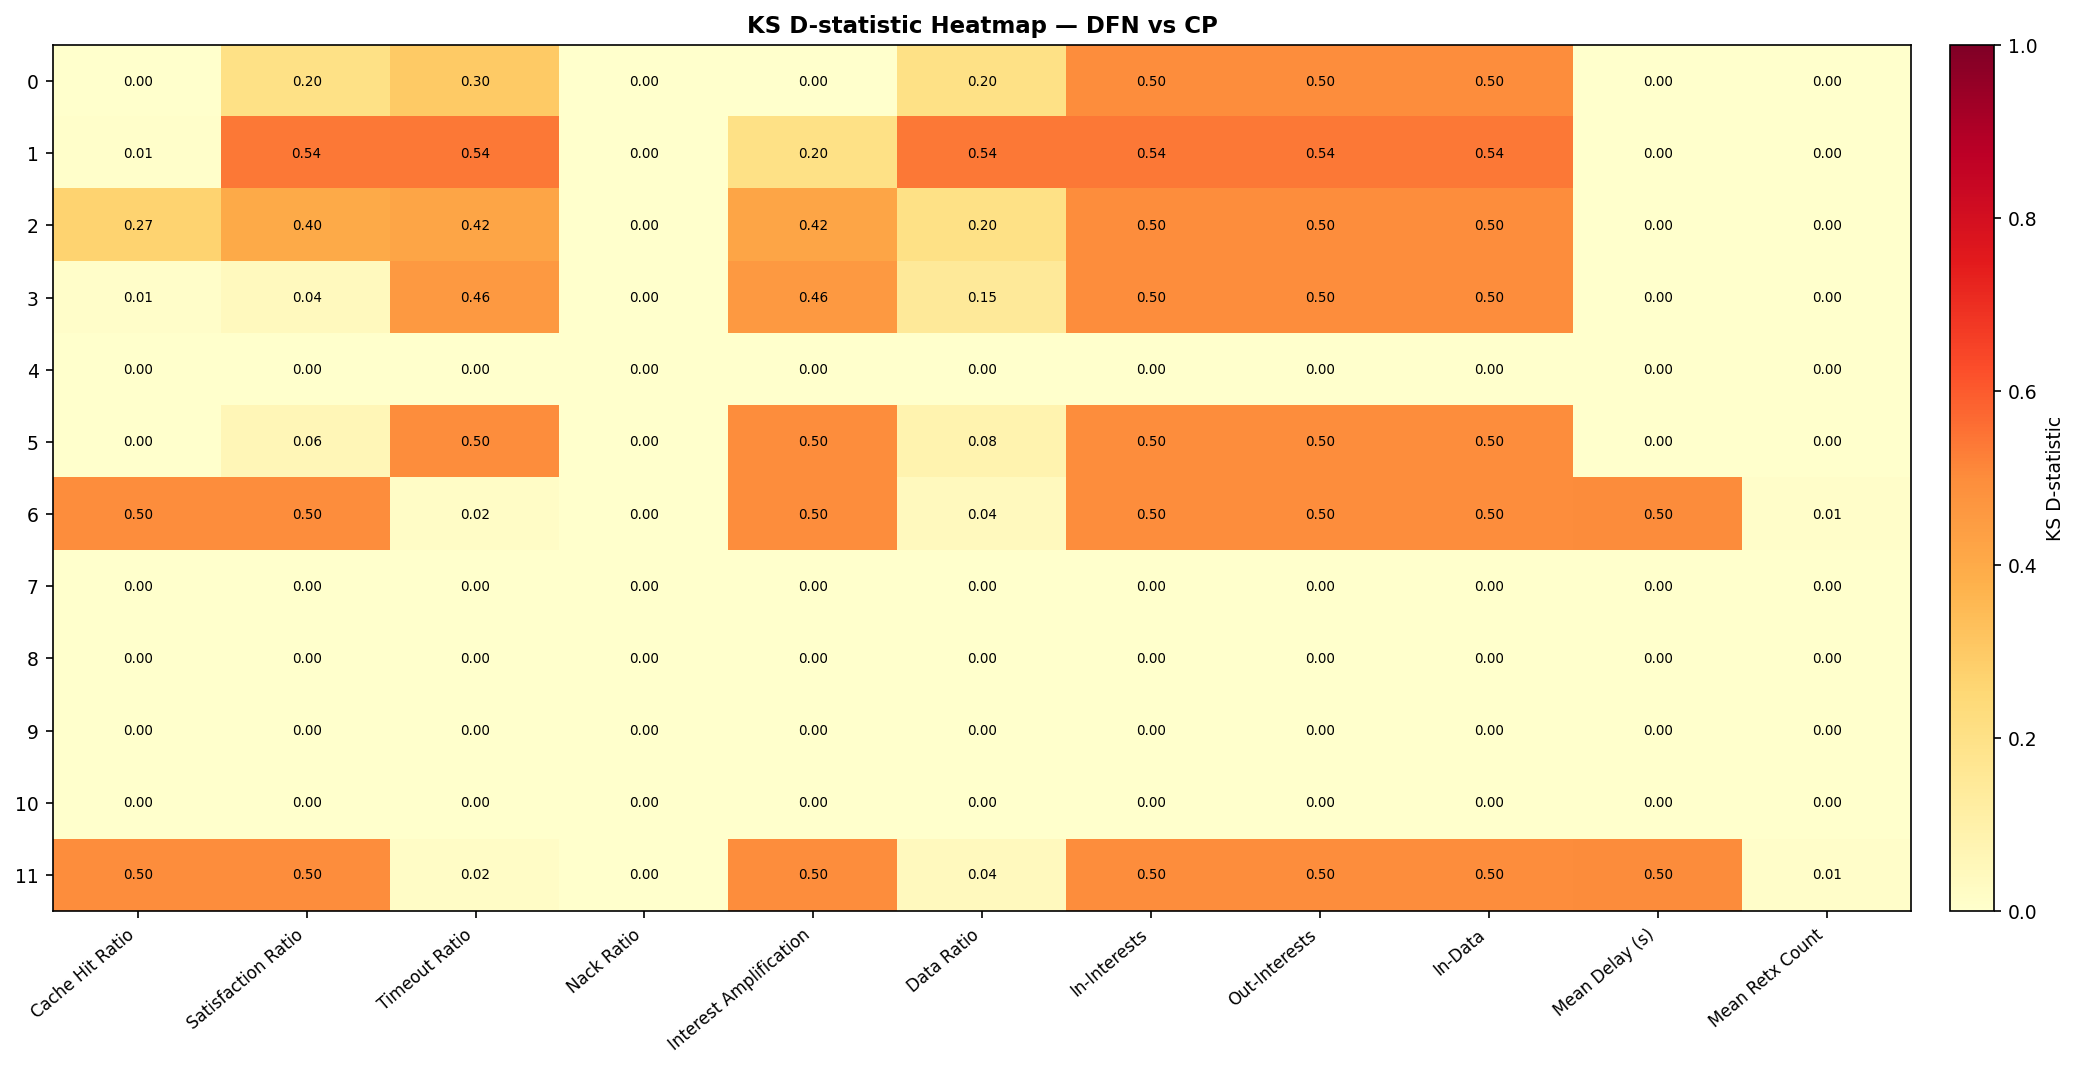

Saved fig_ks_heatmap_dfn_cp.png


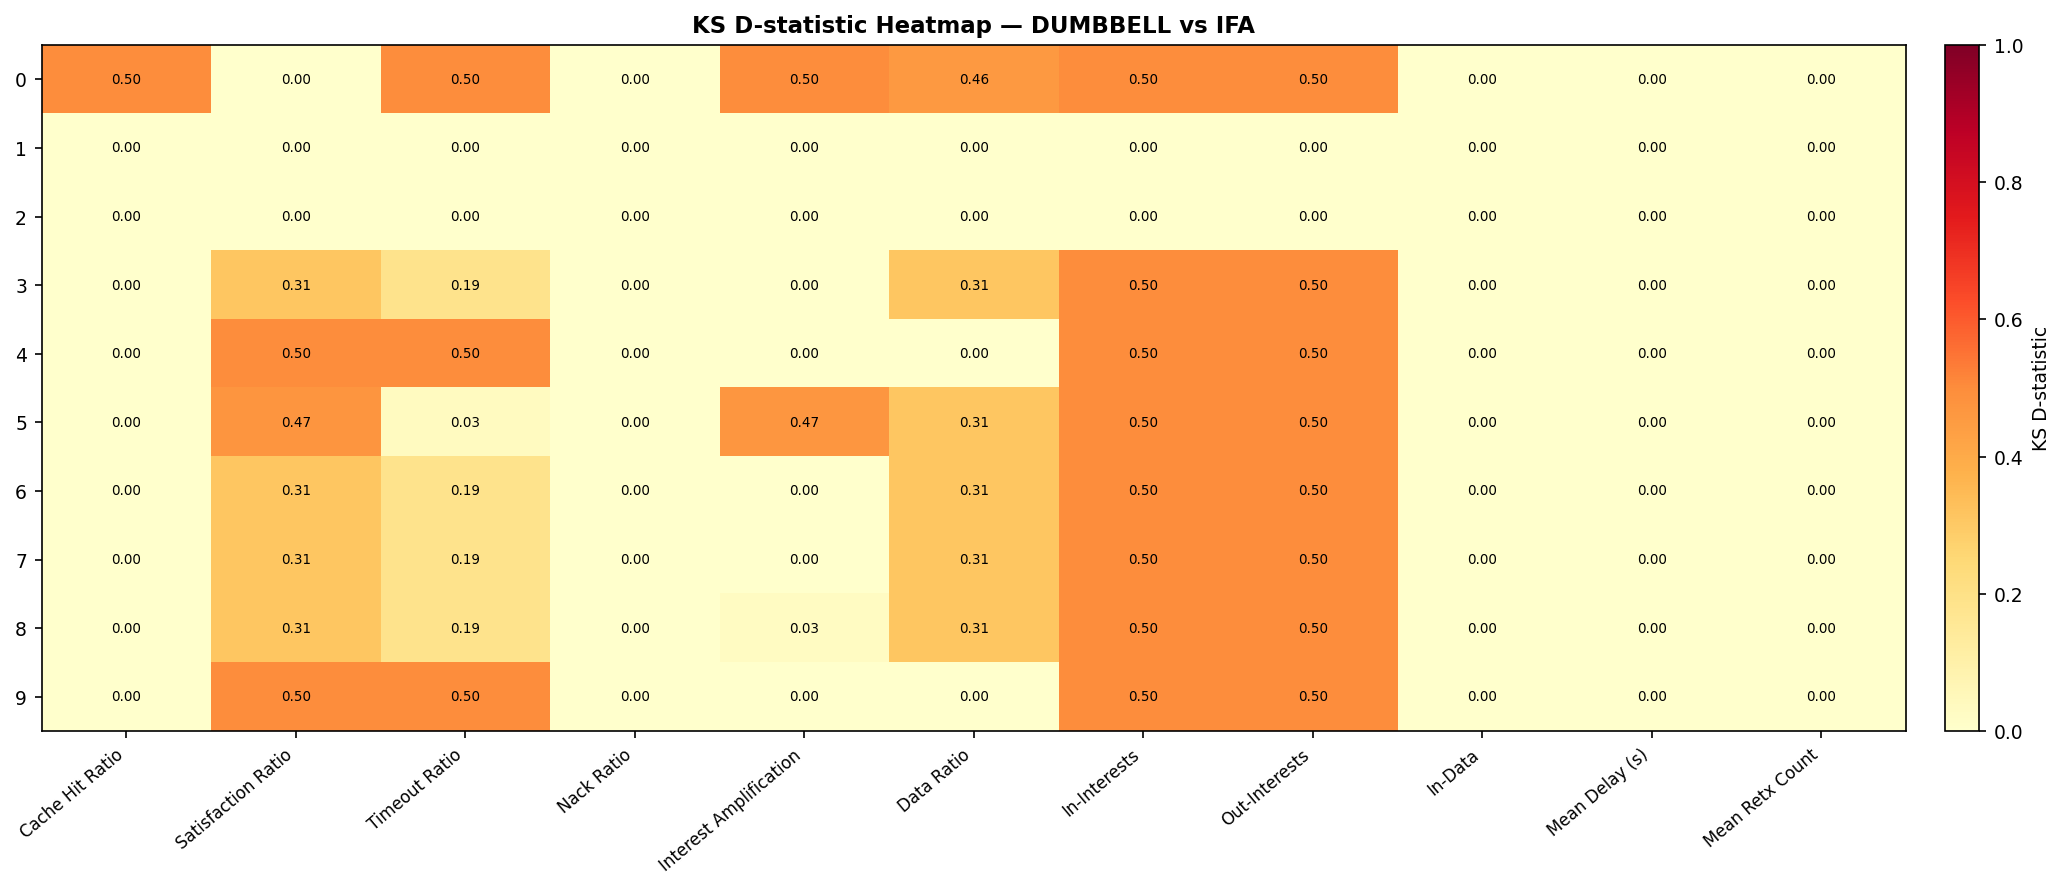

Saved fig_ks_heatmap_dumbbell_ifa.png


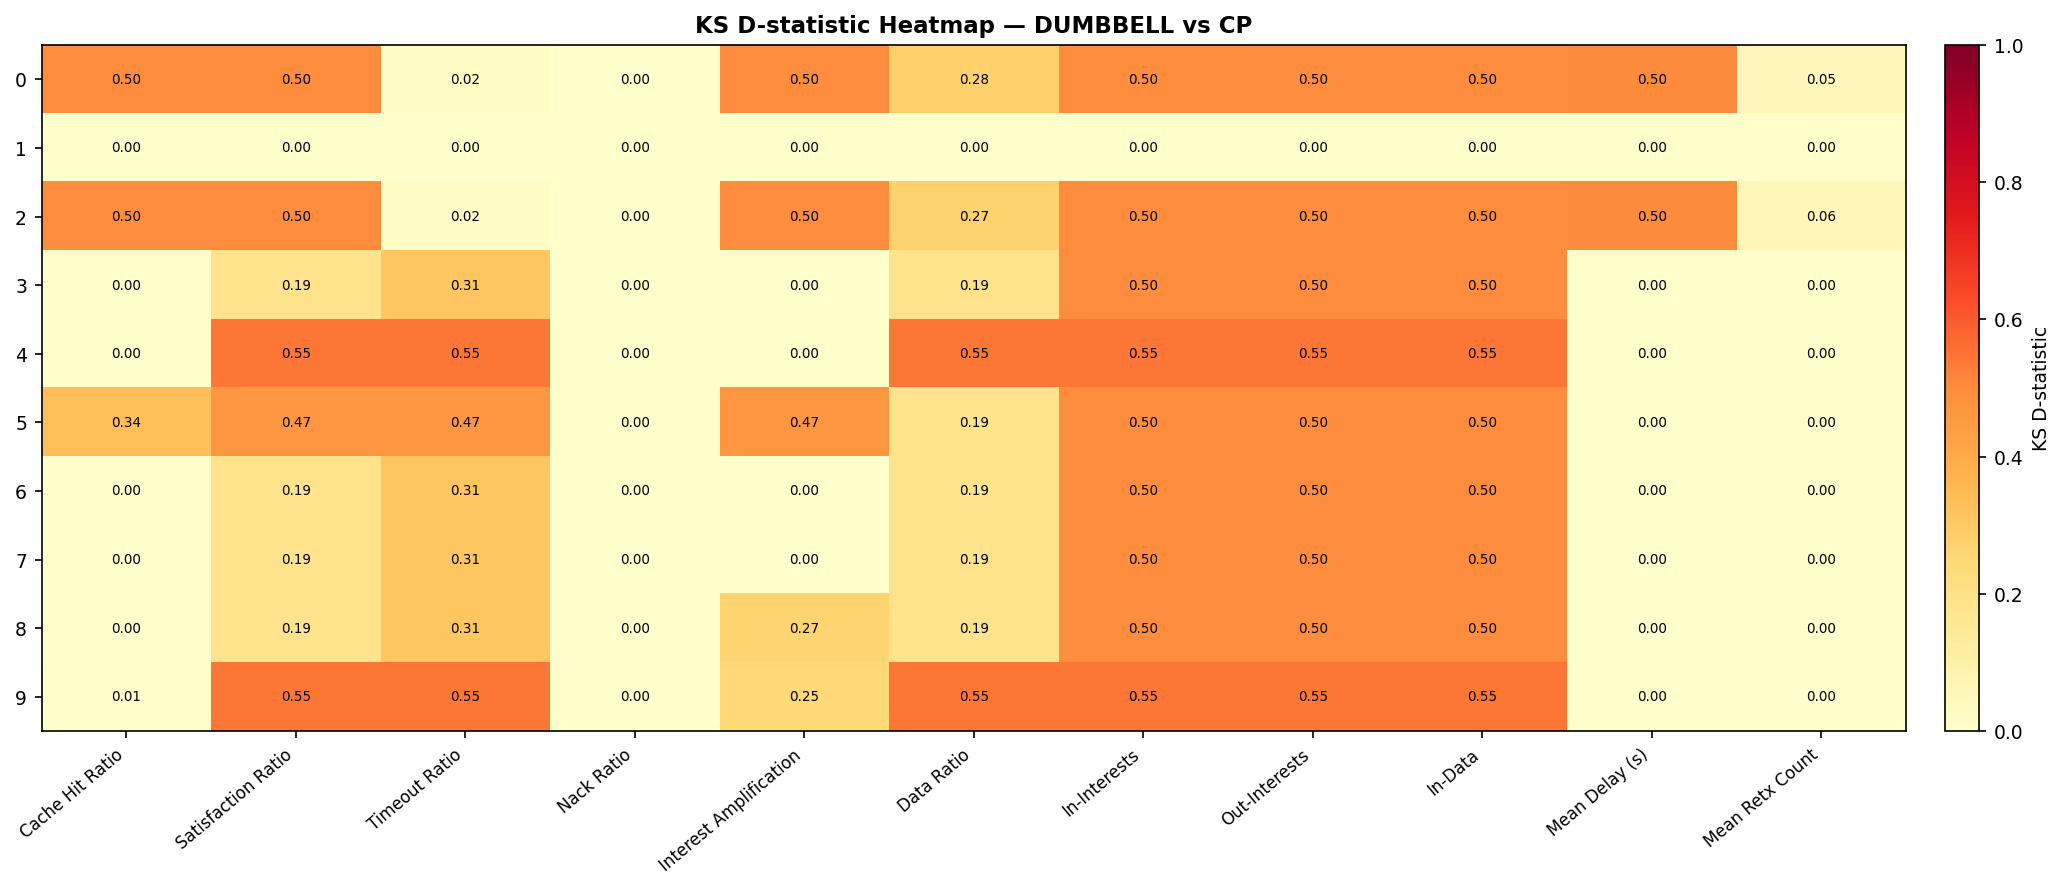

Saved fig_ks_heatmap_dumbbell_cp.png


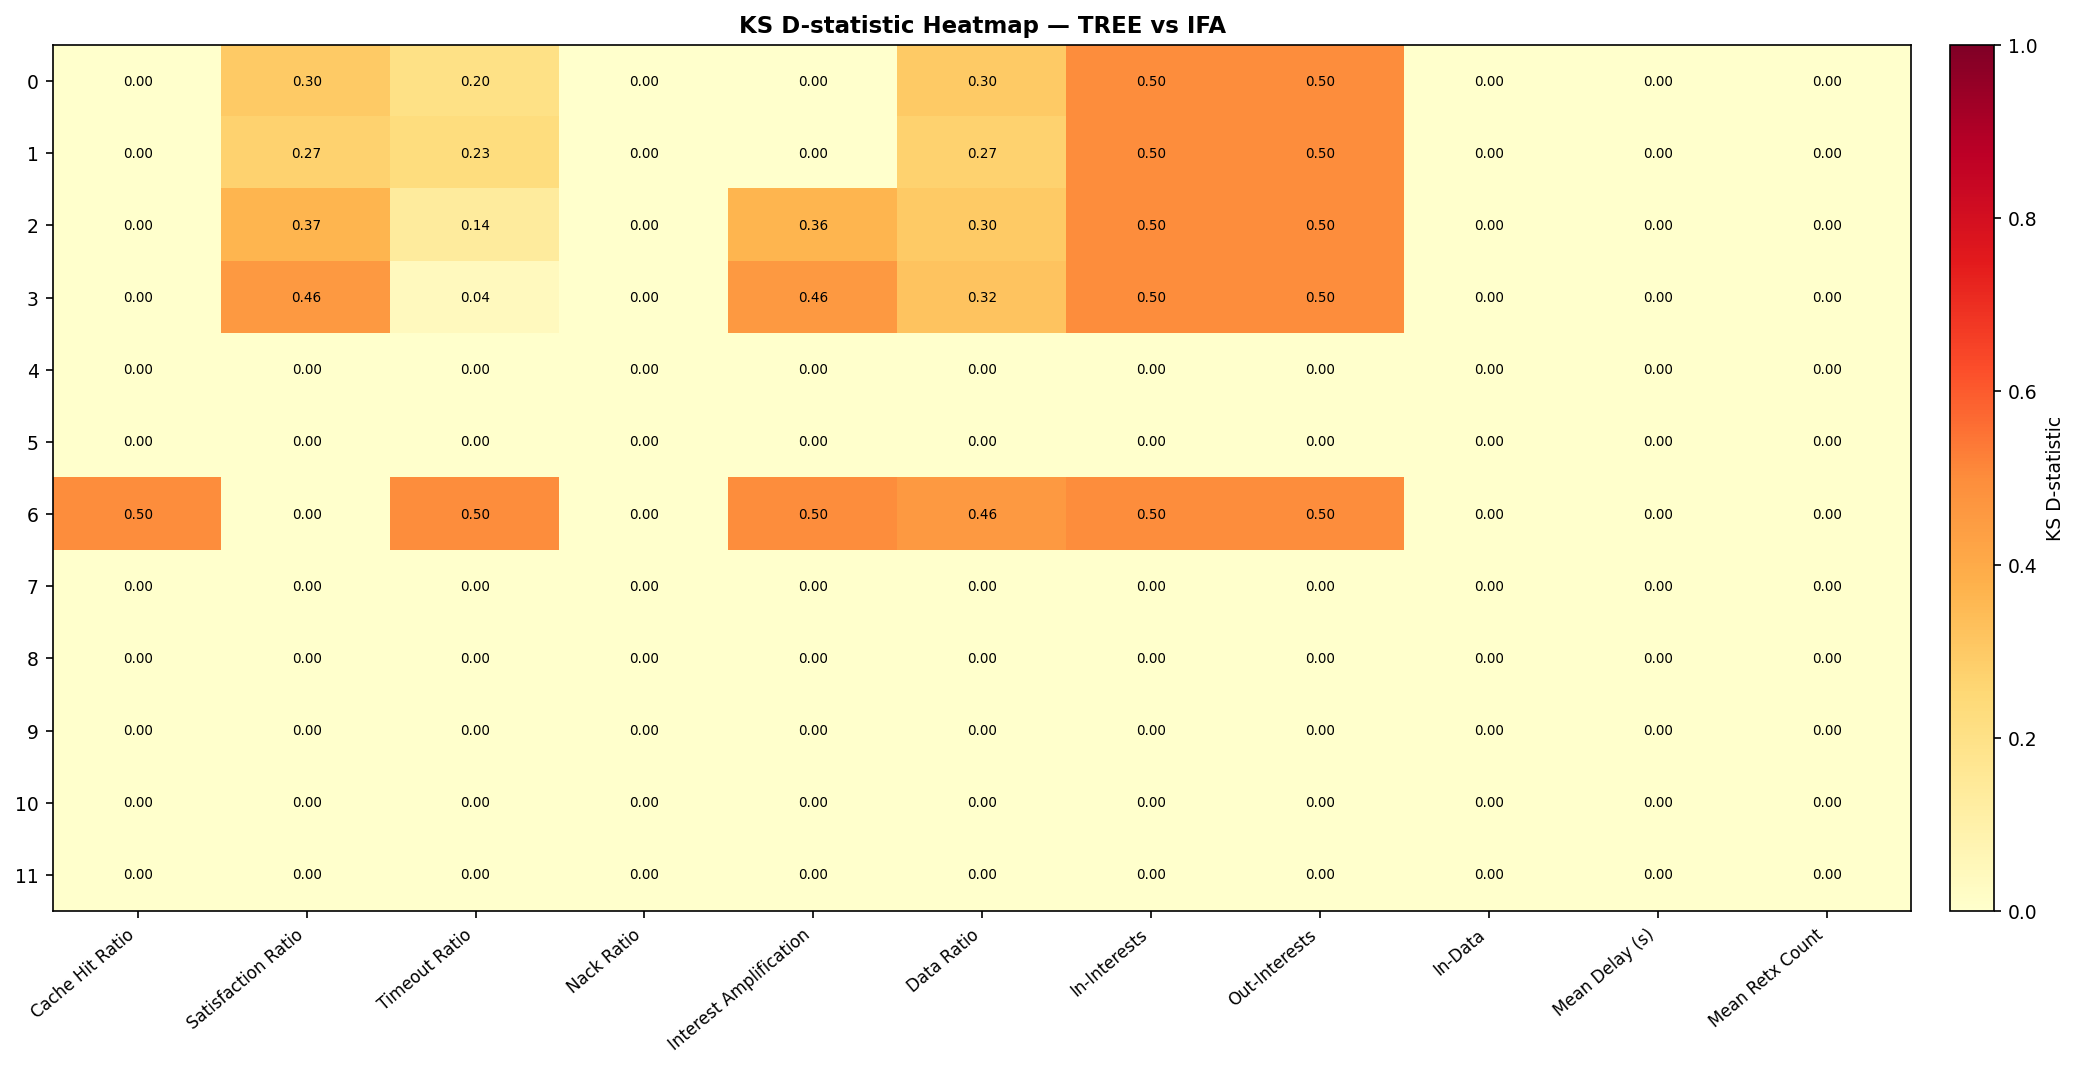

Saved fig_ks_heatmap_tree_ifa.png


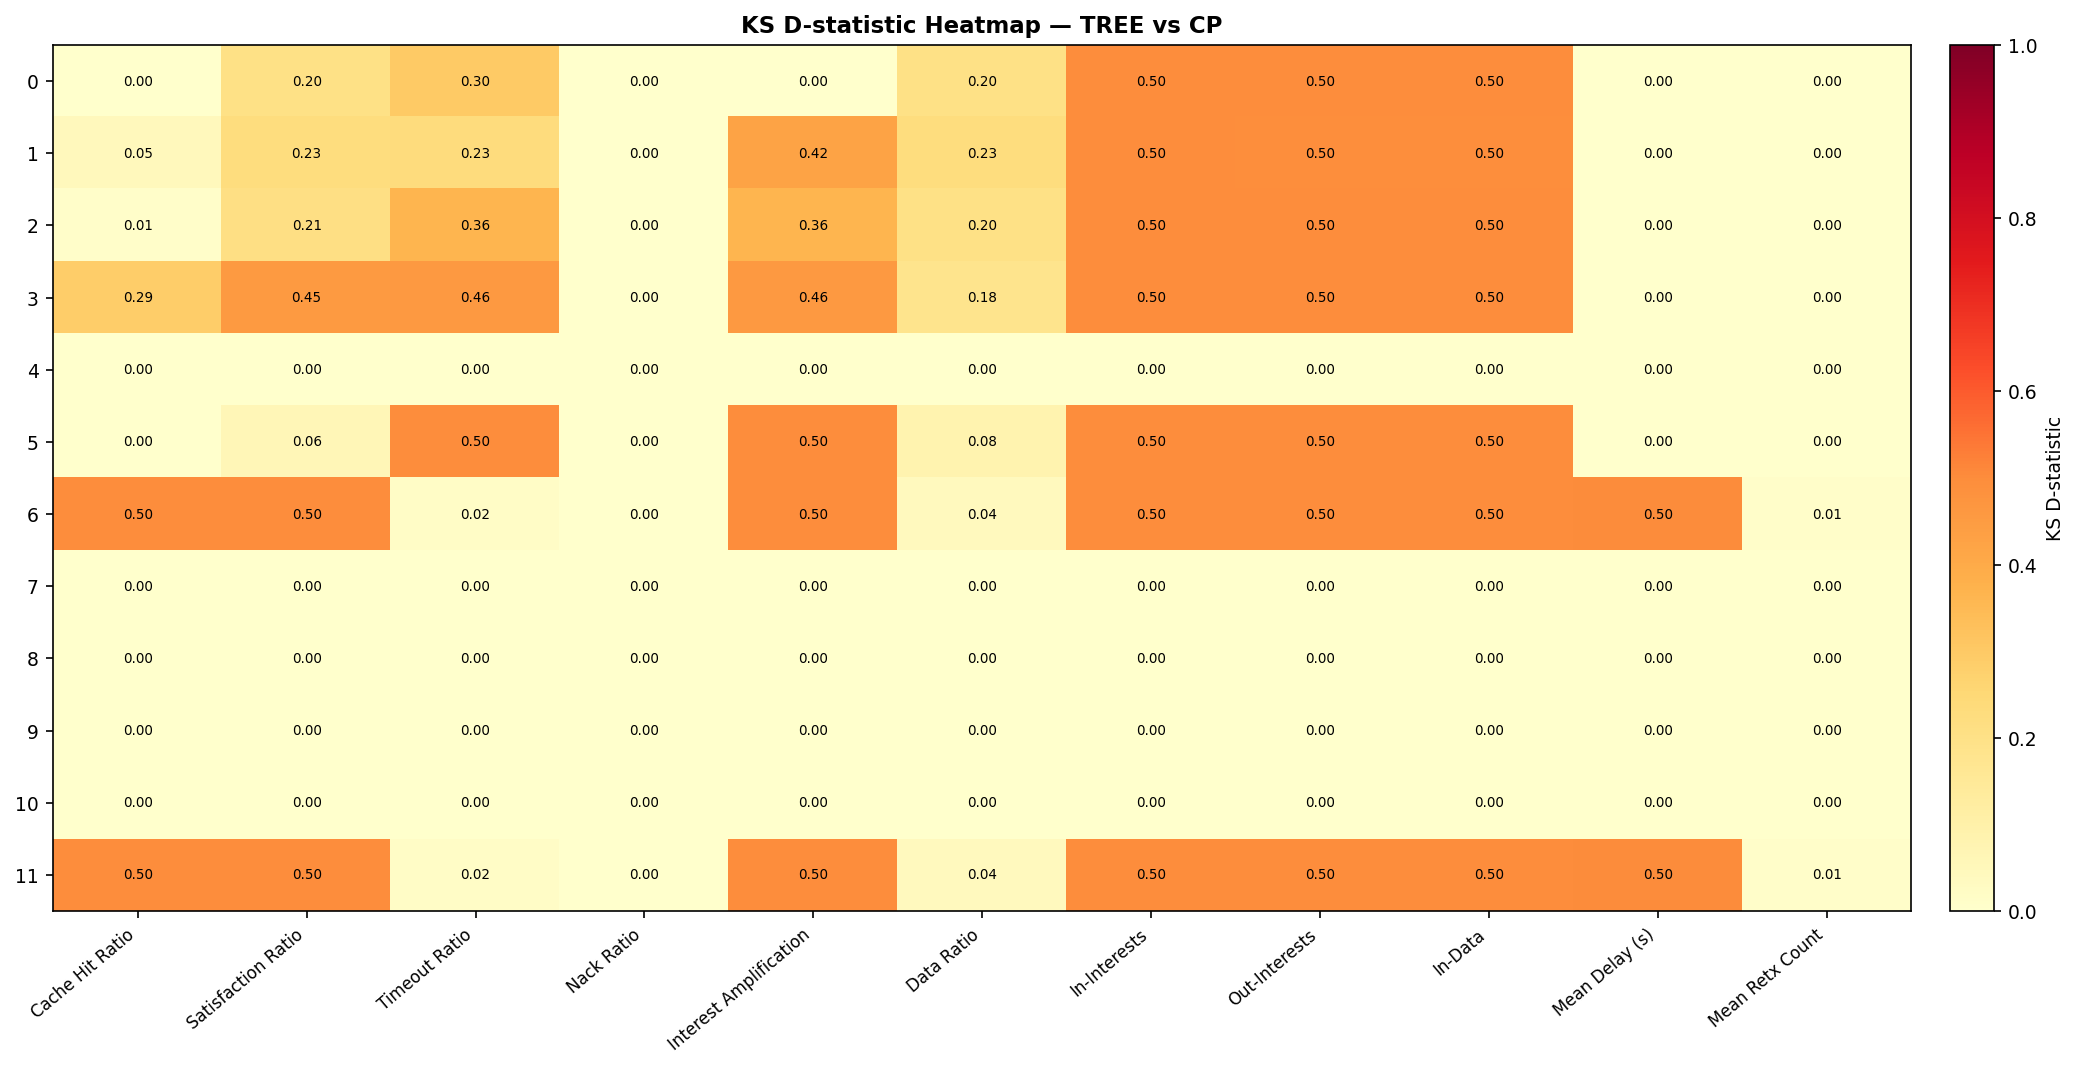

Saved fig_ks_heatmap_tree_cp.png


In [8]:
def plot_ks_heatmap(topo, attack):
    nodes   = sorted(full[full["topology"]==topo]["Node"].unique())
    df_topo = df_ks[(df_ks["topology"]==topo) & (df_ks["attack"]==attack)]

    matrix = np.zeros((len(nodes), len(FEATURES)))
    for ri, node in enumerate(nodes):
        for ci, feat in enumerate(FEATURES):
            row = df_topo[(df_topo["node"]==node) & (df_topo["feature"]==feat)]
            if not row.empty and not np.isnan(row["ks_stat"].values[0]):
                matrix[ri, ci] = row["ks_stat"].values[0]

    fig, ax = plt.subplots(figsize=(14, max(4, len(nodes) * 0.6)))
    im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    for ri in range(len(nodes)):
        for ci in range(len(FEATURES)):
            ax.text(ci, ri, f"{matrix[ri, ci]:.2f}",
                    ha="center", va="center", fontsize=6.5,
                    color="white" if matrix[ri, ci] > 0.7 else "black")

    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels([FEAT_LABELS[f] for f in FEATURES],
                       rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(nodes)))
    ax.set_yticklabels(nodes, fontsize=9)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("KS D-statistic", fontsize=9)

    ax.set_title(
        f"KS D-statistic Heatmap — {topo.upper()} vs {attack.upper()}",
        fontsize=11, fontweight="bold")
    plt.tight_layout()
    fname = FIG_DIR / f"fig_ks_heatmap_{topo}_{attack}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    for attack in ["ifa", "cp"]:
        plot_ks_heatmap(topo, attack)

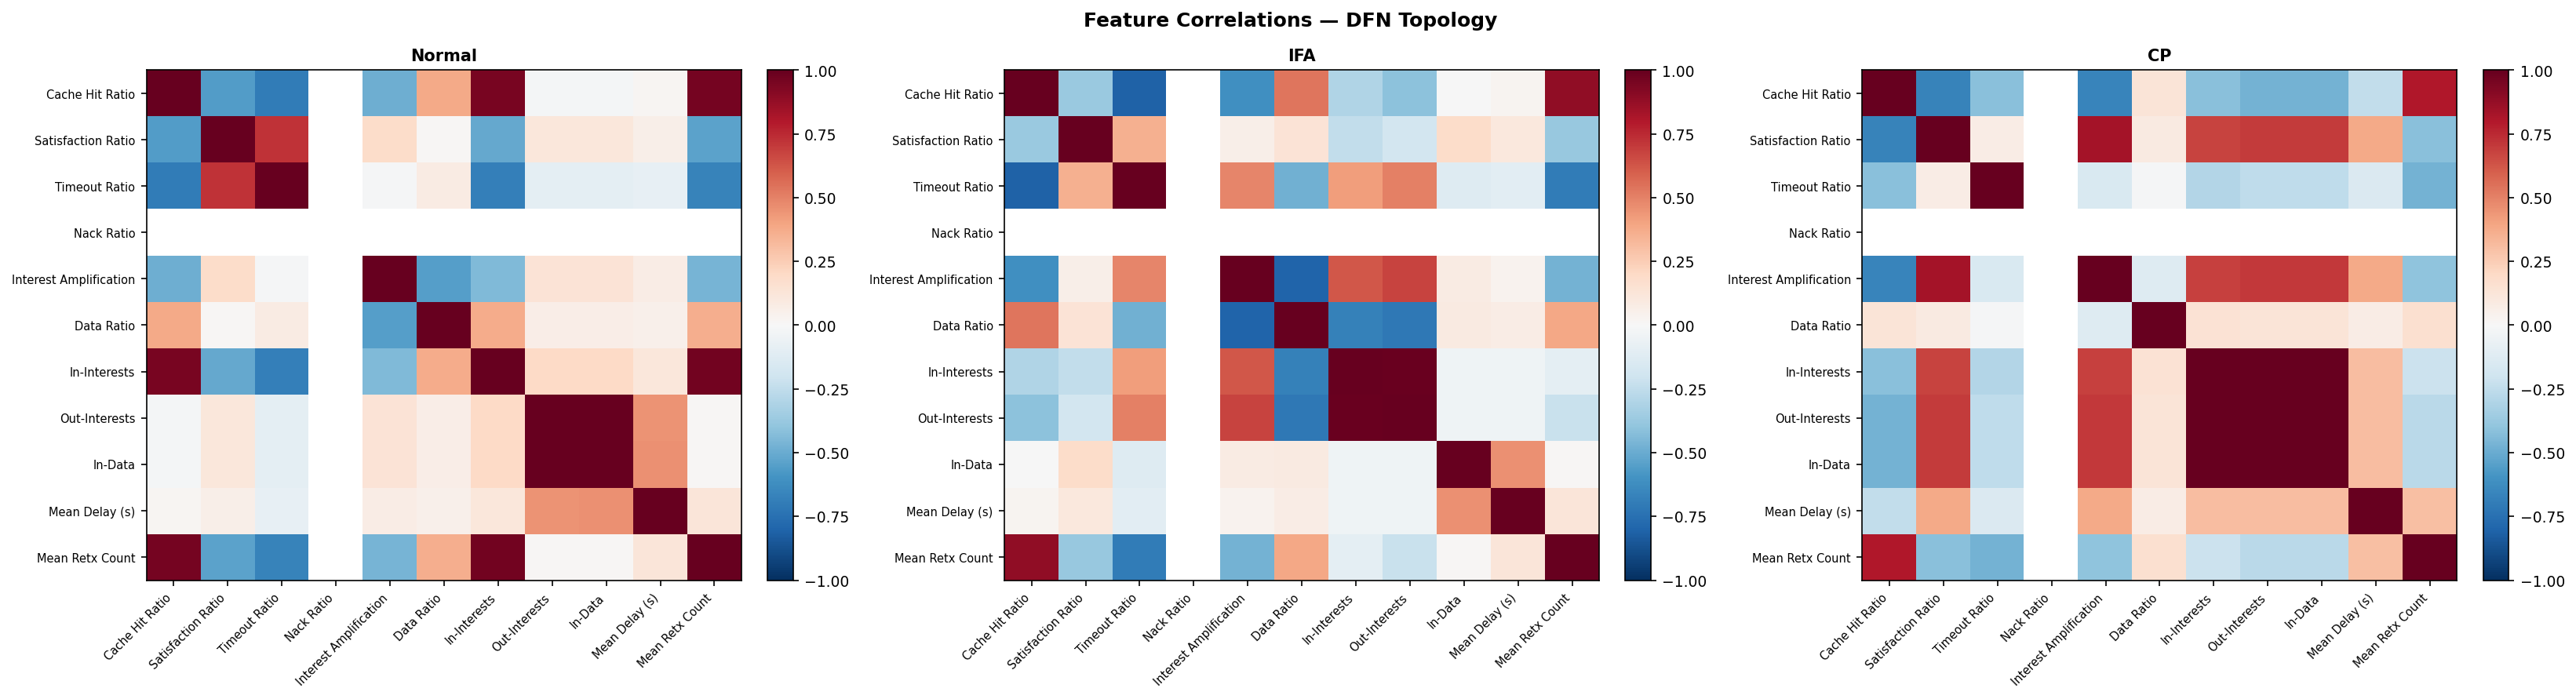

Saved fig_correlation_dfn.png


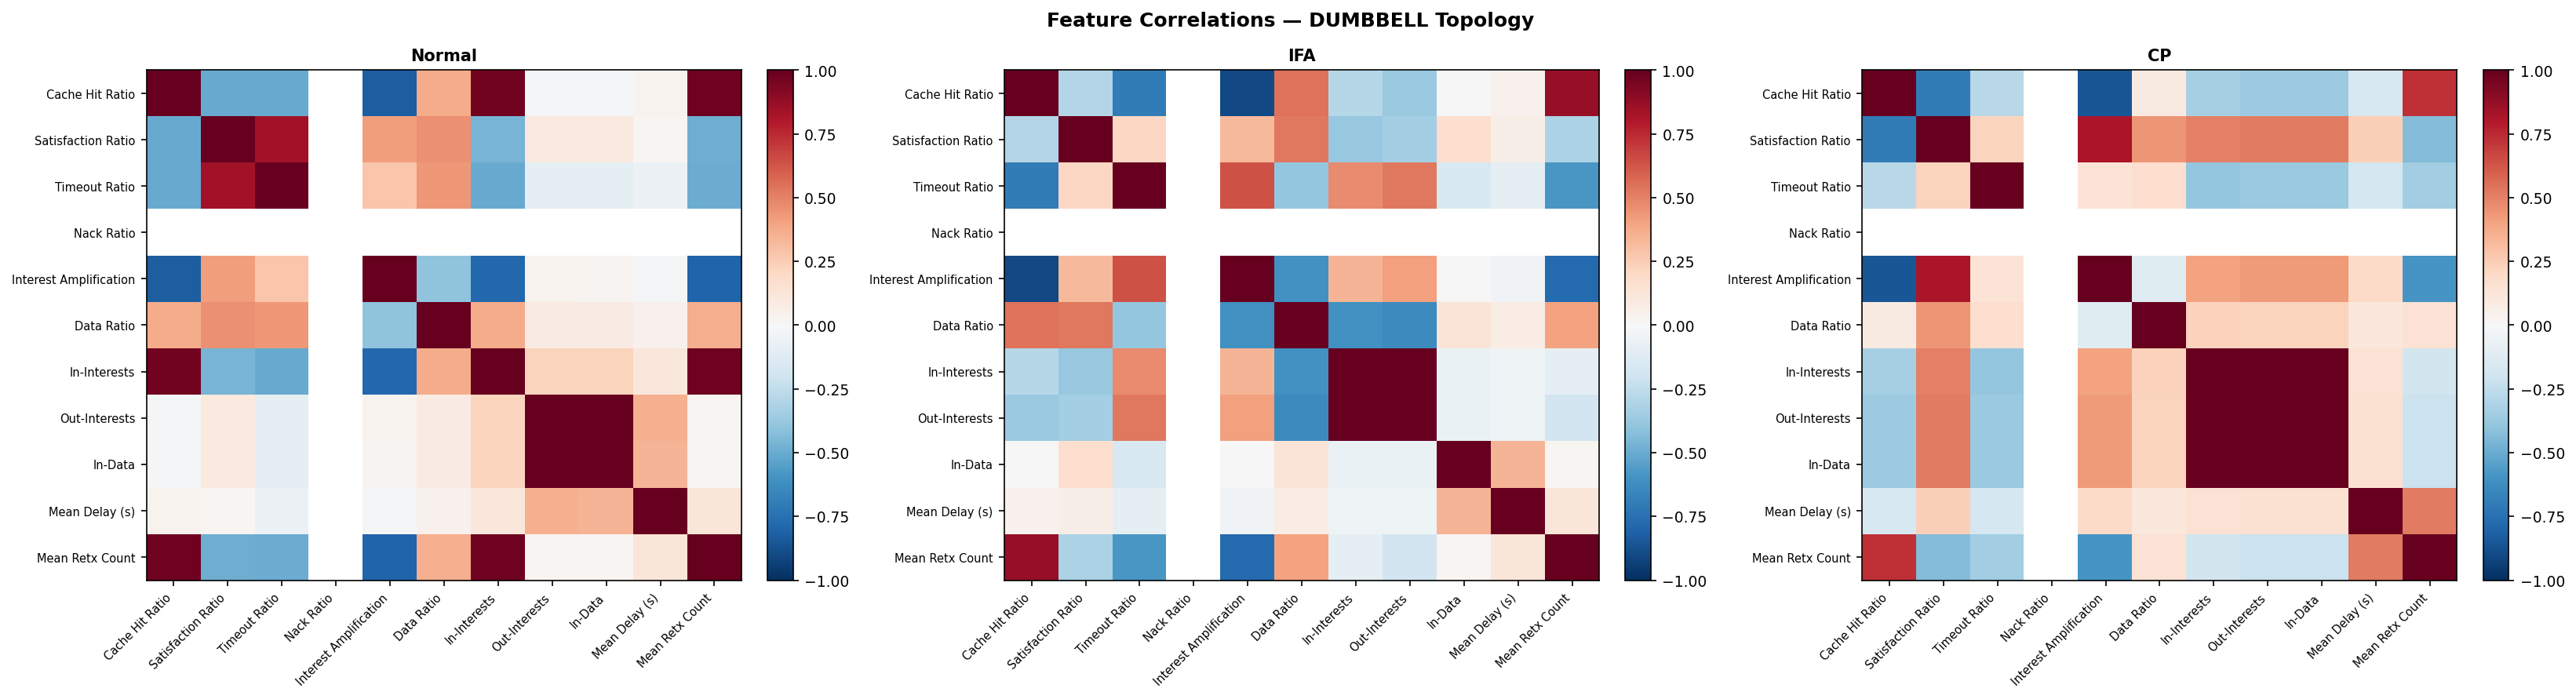

Saved fig_correlation_dumbbell.png


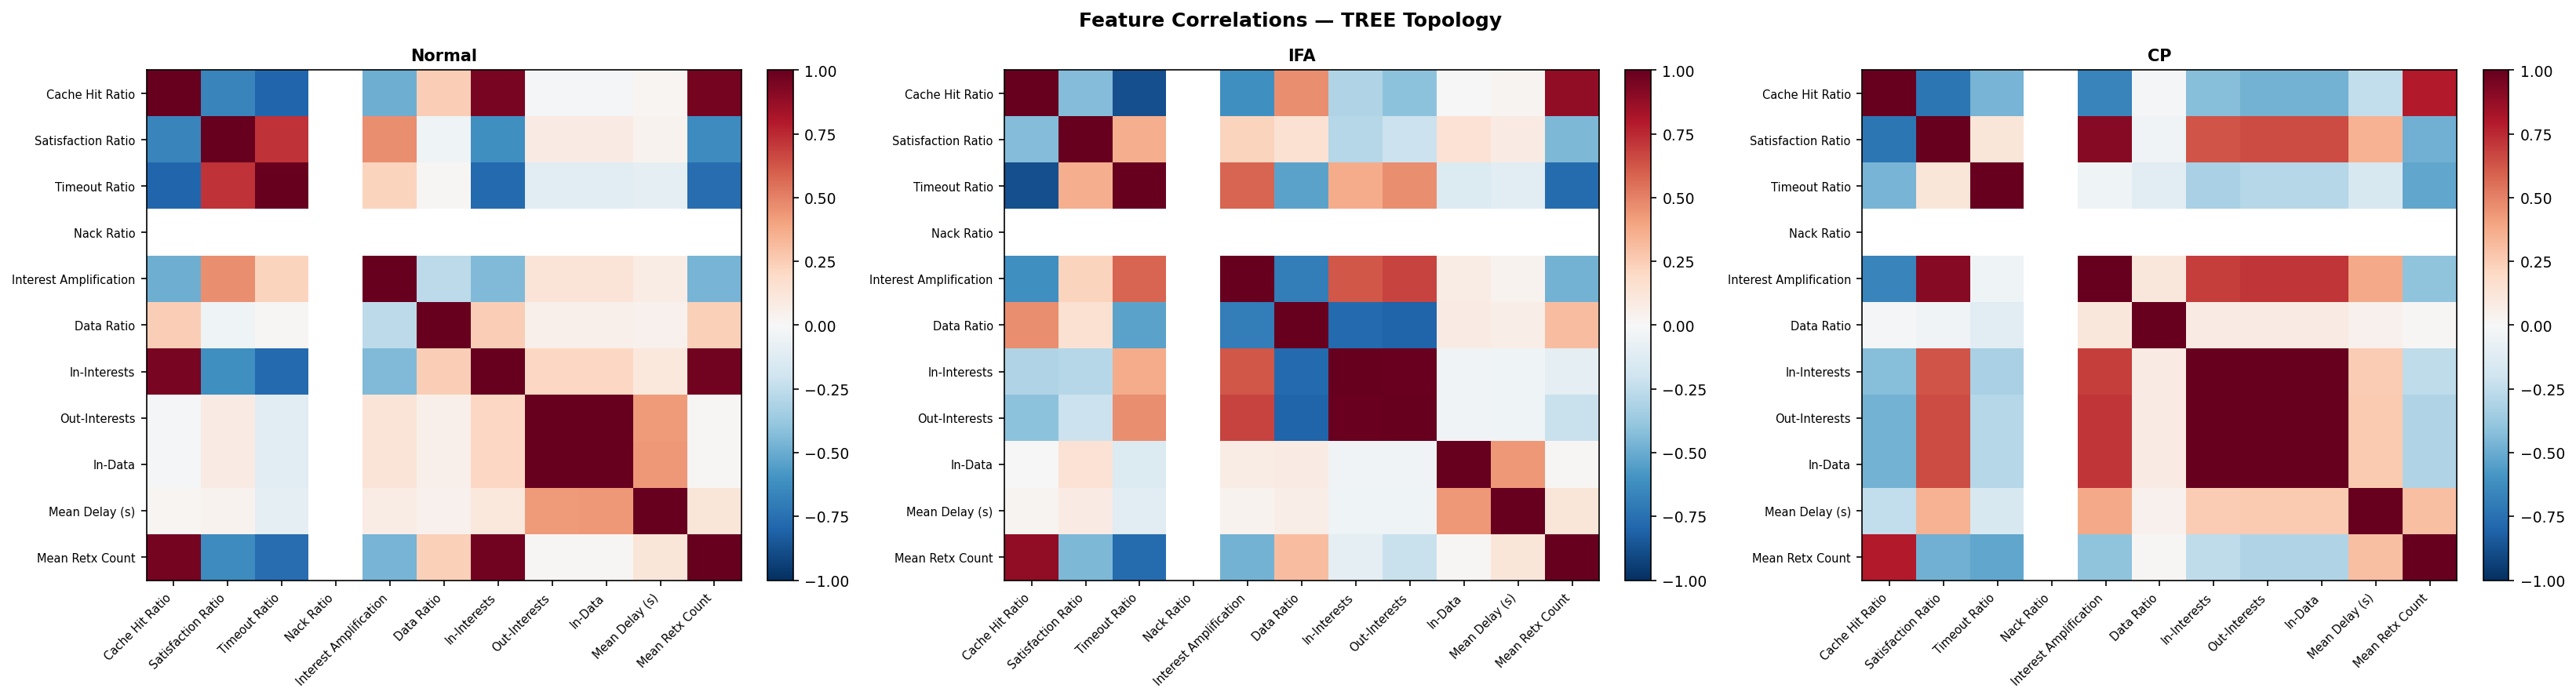

Saved fig_correlation_tree.png


In [9]:
def plot_correlations(topo):
    df_norm = data[topo]["normal"]
    df_ifa  = data[topo]["ifa"]
    df_cp   = data[topo]["cp"]

    corr_norm = df_norm[FEATURES].corr()
    corr_ifa  = df_ifa[FEATURES].corr()
    corr_cp   = df_cp[FEATURES].corr()

    labels = [FEAT_LABELS[f] for f in FEATURES]

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    for ax, corr_mat, title in [
        (axes[0], corr_norm, "Normal"),
        (axes[1], corr_ifa,  "IFA"),
        (axes[2], corr_cp,   "CP")
    ]:
        im = ax.imshow(corr_mat.values, cmap="RdBu_r",
                       vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(FEATURES)))
        ax.set_yticks(range(len(FEATURES)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_title(title, fontsize=10, fontweight="bold")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Feature Correlations — {topo.upper()} Topology",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    fname = FIG_DIR / f"fig_correlation_{topo}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname.name}")

for topo in TOPOLOGIES:
    plot_correlations(topo)

In [10]:
print("=" * 65)
print("Top 5 Features by Mean KS Statistic (Normal vs IFA)")
print("=" * 65)
ifa_ks = df_ks[df_ks["attack"]=="ifa"].groupby("feature")["ks_stat"].mean().sort_values(ascending=False)
print(ifa_ks.round(3).to_string())

print("\n" + "=" * 65)
print("Top 5 Features by Mean KS Statistic (Normal vs CP)")
print("=" * 65)
cp_ks = df_ks[df_ks["attack"]=="cp"].groupby("feature")["ks_stat"].mean().sort_values(ascending=False)
print(cp_ks.round(3).to_string())

print("\n" + "=" * 65)
print("KS Stats by Role (IFA)")
print("=" * 65)
print(df_ks[df_ks["attack"]=="ifa"].groupby(["role","feature"])["ks_stat"]
      .mean().round(3).unstack("feature").T.to_string())

Top 5 Features by Mean KS Statistic (Normal vs IFA)
feature
OutInterests          0.265
InInterests           0.264
satisfaction_ratio    0.171
data_ratio            0.149
timeout_ratio         0.138
interest_amp          0.109
cache_hit_ratio       0.045
InData                0.000
delay_mean            0.000
nack_ratio            0.000
retx_mean             0.000

Top 5 Features by Mean KS Statistic (Normal vs CP)
feature
OutInterests          0.342
InInterests           0.342
InData                0.341
satisfaction_ratio    0.227
interest_amp          0.215
timeout_ratio         0.205
data_ratio            0.141
cache_hit_ratio       0.117
delay_mean            0.088
retx_mean             0.005
nack_ratio            0.000

KS Stats by Role (IFA)
role                consumer  router
feature                             
InData                 0.000   0.000
InInterests            0.101   0.394
OutInterests           0.101   0.394
cache_hit_ratio        0.100   0.000
data_ratio        